In [1]:
import os
import glob
import numpy as np
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import ExcelWriter
from sklearn.model_selection import GridSearchCV

## Case: 5-years-old/ healthy

In [4]:
df_5Y = pd.read_excel("Case5Y_DPM.xlsx")
df_5Y

,10,20,30,40,50,60,70,80,90,100,Flow Rate[L/min],Velocity,Half Cone angle,region,name
0,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Vestibule,0
1,0.000000,3.130000,6.60,5.970000,6.260000,6.710000,6.010000,6.900000,6.320000,6.560000,8.7,19.2,16.0,Nasal Valve,1
2,0.340000,1.880000,3.67,3.860000,3.580000,4.120000,3.800000,3.900000,3.560000,4.250000,8.7,19.2,16.0,Anterior Turbinate,2
3,0.100000,0.780000,0.19,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Nasopharynx,3
4,5.520000,3.680000,0.12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Outlet,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.000000,0.000000,0.00,0.000000,0.000000,0.060000,0.306667,0.926667,1.346667,2.013333,15.0,2.0,39.5,Vestibule,0
116,0.206667,7.986667,9.60,7.746667,7.826667,8.453333,7.460000,7.953333,6.913333,7.180000,15.0,2.0,39.5,Nasal Valve,1
117,4.573333,1.960000,1.40,2.253333,2.173333,2.486667,2.233333,2.120000,1.733333,1.800000,15.0,2.0,39.5,Anterior Turbinate,2
118,0.186667,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.0,2.0,39.5,Nasopharynx,3


In [5]:
df_5Y_melt=pd.melt(df_5Y,id_vars=['Flow Rate[L/min]','region', 'name', 'Velocity','Half Cone angle'],
           value_vars=[10,20,30,40,50,60,70,80,90,100],
           value_name='Dose')
df_5Y_melt

,Flow Rate[L/min],region,name,Velocity,Half Cone angle,variable,Dose
0,8.7,Vestibule,0,19.2,16.0,10,0.000000
1,8.7,Nasal Valve,1,19.2,16.0,10,0.000000
2,8.7,Anterior Turbinate,2,19.2,16.0,10,0.340000
3,8.7,Nasopharynx,3,19.2,16.0,10,0.100000
4,8.7,Outlet,4,19.2,16.0,10,5.520000
...,...,...,...,...,...,...,...
1195,15.0,Vestibule,0,2.0,39.5,100,2.013333
1196,15.0,Nasal Valve,1,2.0,39.5,100,7.180000
1197,15.0,Anterior Turbinate,2,2.0,39.5,100,1.800000
1198,15.0,Nasopharynx,3,2.0,39.5,100,0.000000


In [6]:
df_5Y_melt = df_5Y_melt.rename(columns={"variable":"diameter"})
df_5Y_melt = df_5Y_melt.rename(columns={"name":"region in nose"})

df_5Y_melt['region in nose']=df_5Y_melt['region in nose'].astype('float64')
df_5Y_melt['diameter']=df_5Y_melt['diameter'].astype('float64')


X=df_5Y_melt.loc[:,['Flow Rate[L/min]', 'region in nose', 'diameter','Velocity','Half Cone angle']]
Y =df_5Y_melt.loc[:,'Dose']

In [7]:
df_5Y_melt

,Flow Rate[L/min],region,region in nose,Velocity,Half Cone angle,diameter,Dose
0,8.7,Vestibule,0.0,19.2,16.0,10.0,0.000000
1,8.7,Nasal Valve,1.0,19.2,16.0,10.0,0.000000
2,8.7,Anterior Turbinate,2.0,19.2,16.0,10.0,0.340000
3,8.7,Nasopharynx,3.0,19.2,16.0,10.0,0.100000
4,8.7,Outlet,4.0,19.2,16.0,10.0,5.520000
...,...,...,...,...,...,...,...
1195,15.0,Vestibule,0.0,2.0,39.5,100.0,2.013333
1196,15.0,Nasal Valve,1.0,2.0,39.5,100.0,7.180000
1197,15.0,Anterior Turbinate,2.0,2.0,39.5,100.0,1.800000
1198,15.0,Nasopharynx,3.0,2.0,39.5,100.0,0.000000


C:\Users\DFMRendering\AppData\Local\Temp\ipykernel_15744\1423836050.py:7: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.swarmplot(x="region", y="Dose", data=df_5Y_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 78.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 85.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 10.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\

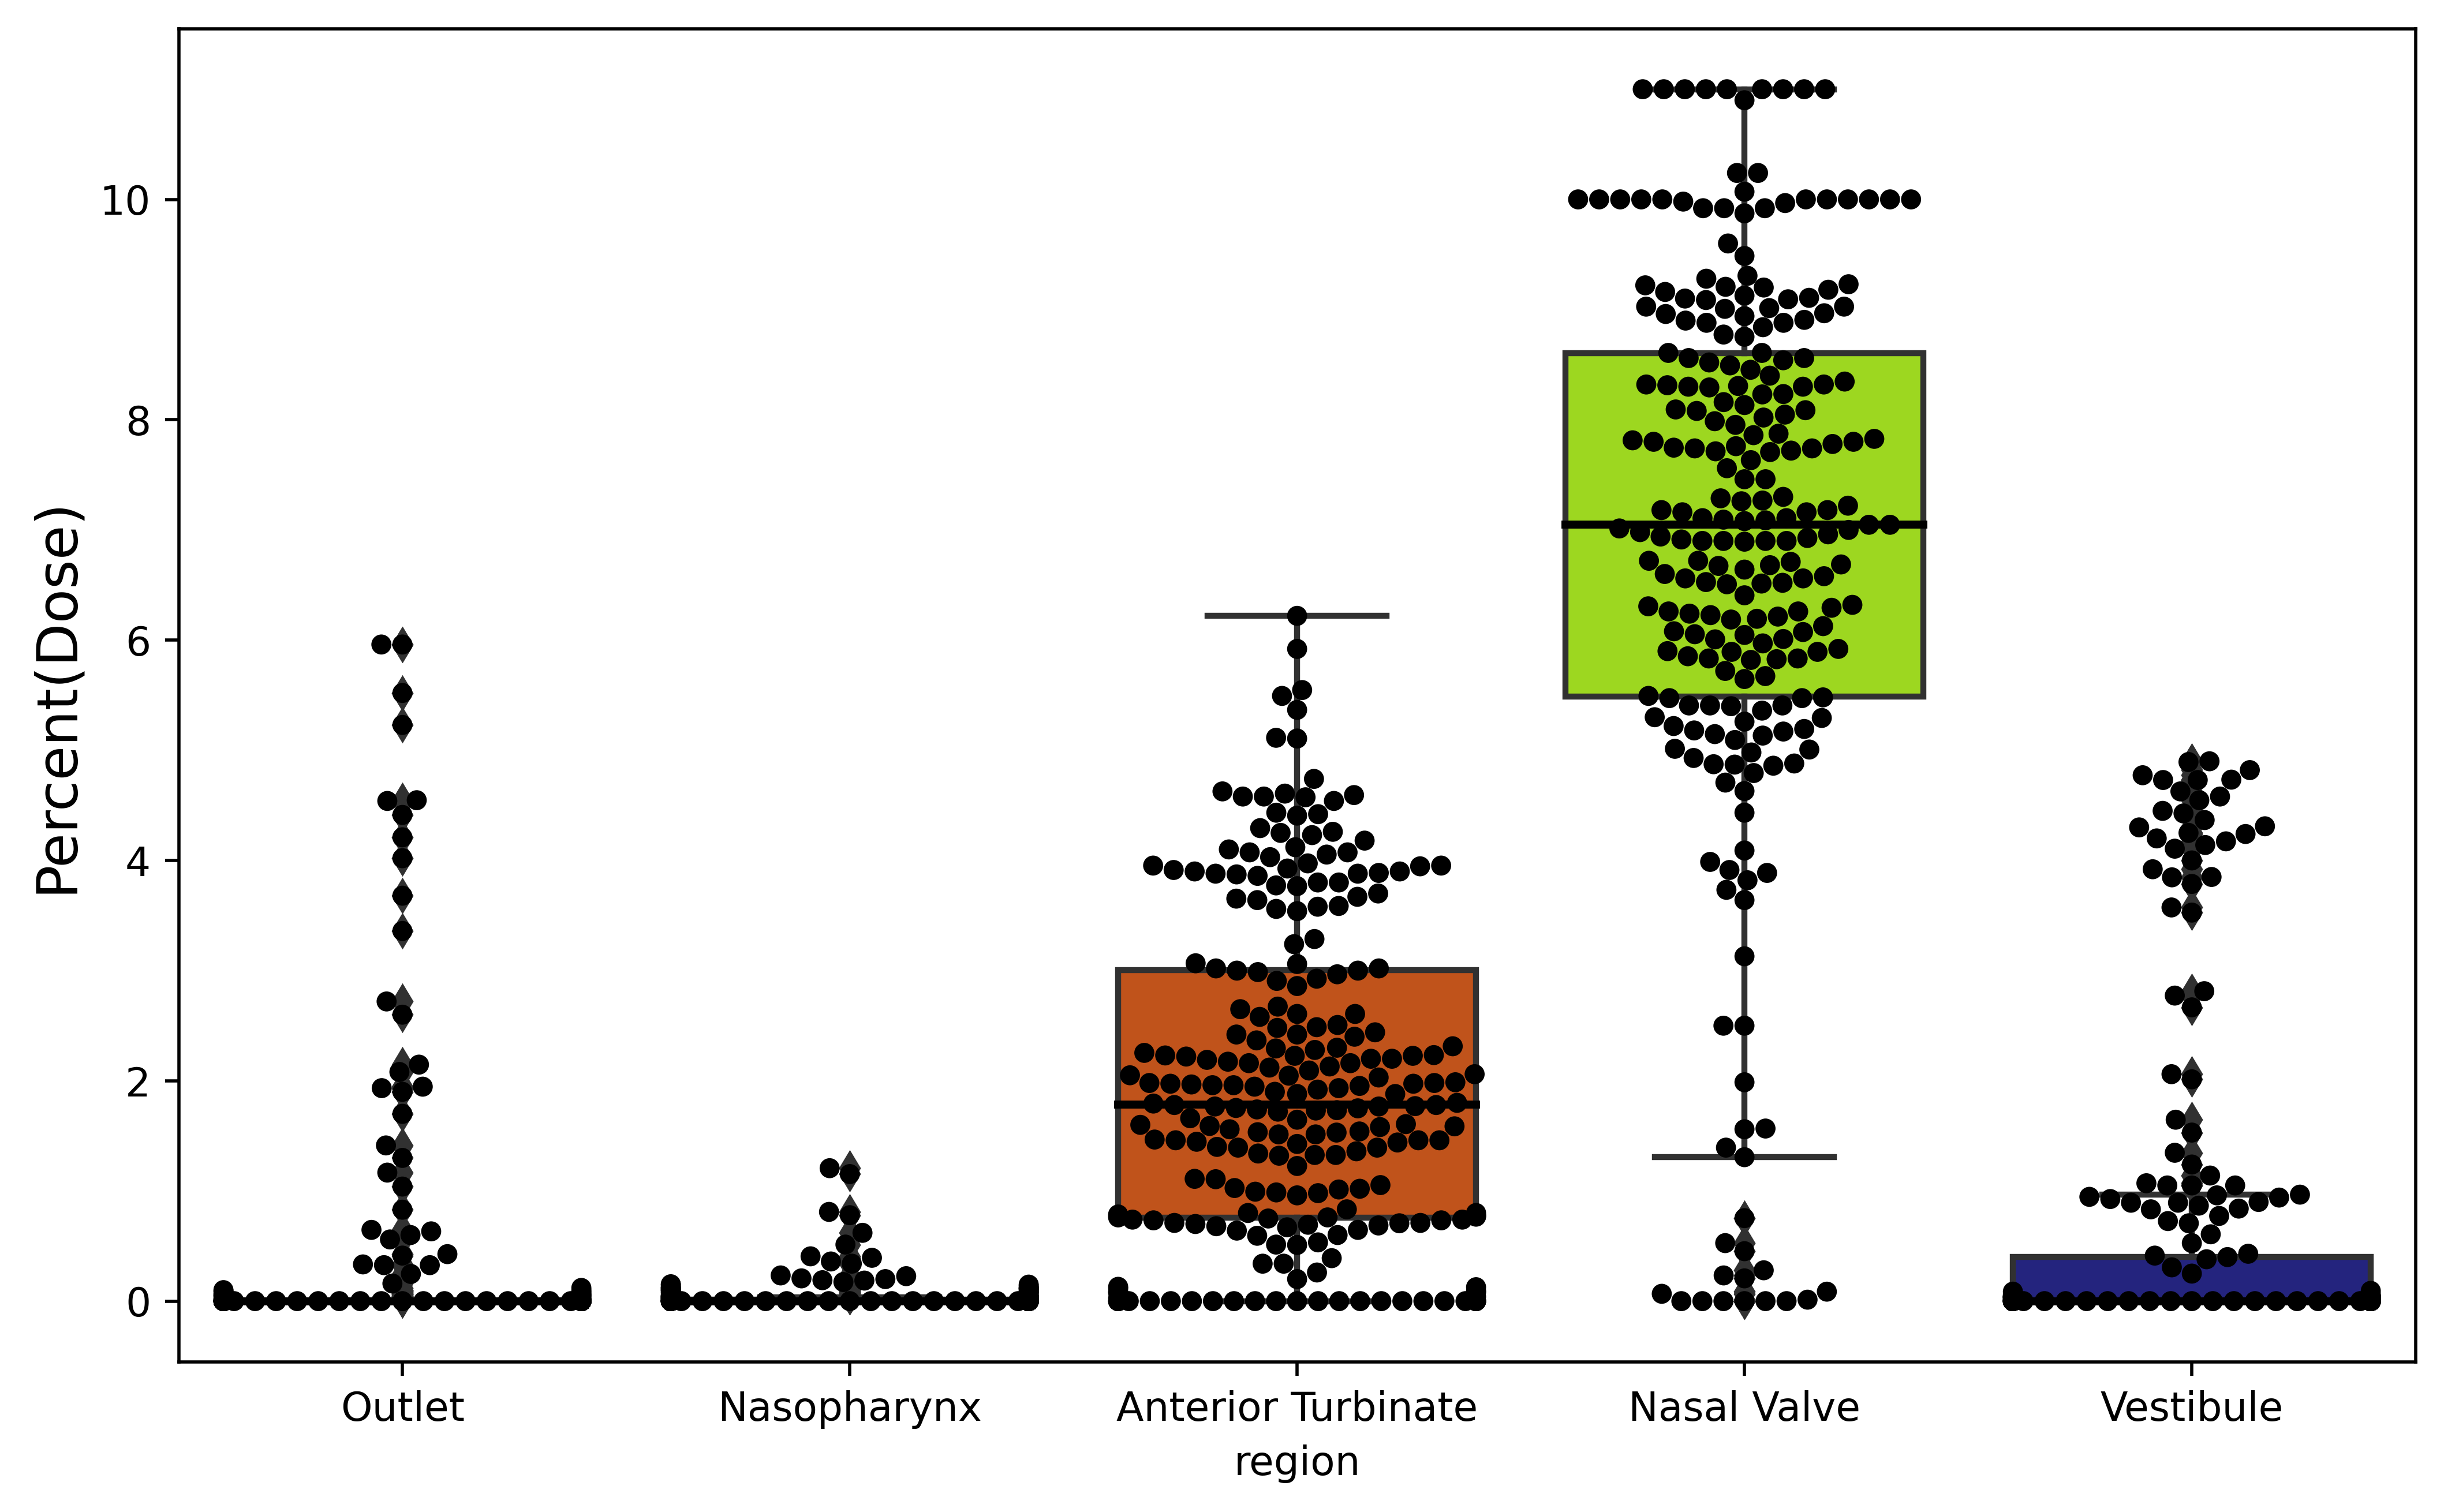

In [9]:
my_pal = {"Vestibule": "#24247e", "Nasal Valve": "#9dd720", "Anterior Turbinate":"#c0531b", "Nasopharynx":"#b61b1c","Outlet":"#DC143C"}
my_pal_2 = {"Vestibule": "black", "Nasal Valve": "black", "Anterior Turbinate":"black", "Nasopharynx":"black", "Outlet":"black"}
medianprops = dict(linestyle='-', linewidth=2, color='black')
plt.figure(figsize=(10,6), dpi = 500)

ax = sns.boxplot(x="region", y="Dose", data=df_5Y_melt, palette=my_pal, saturation=100, medianprops=medianprops, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
ax = sns.swarmplot(x="region", y="Dose", data=df_5Y_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
plt.ylabel('Percent(Dose)', fontsize= 14)
plt.show()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Gradient Boosting :
MSE: 1.1394
MAE: 0.7084
Score: 0.8627


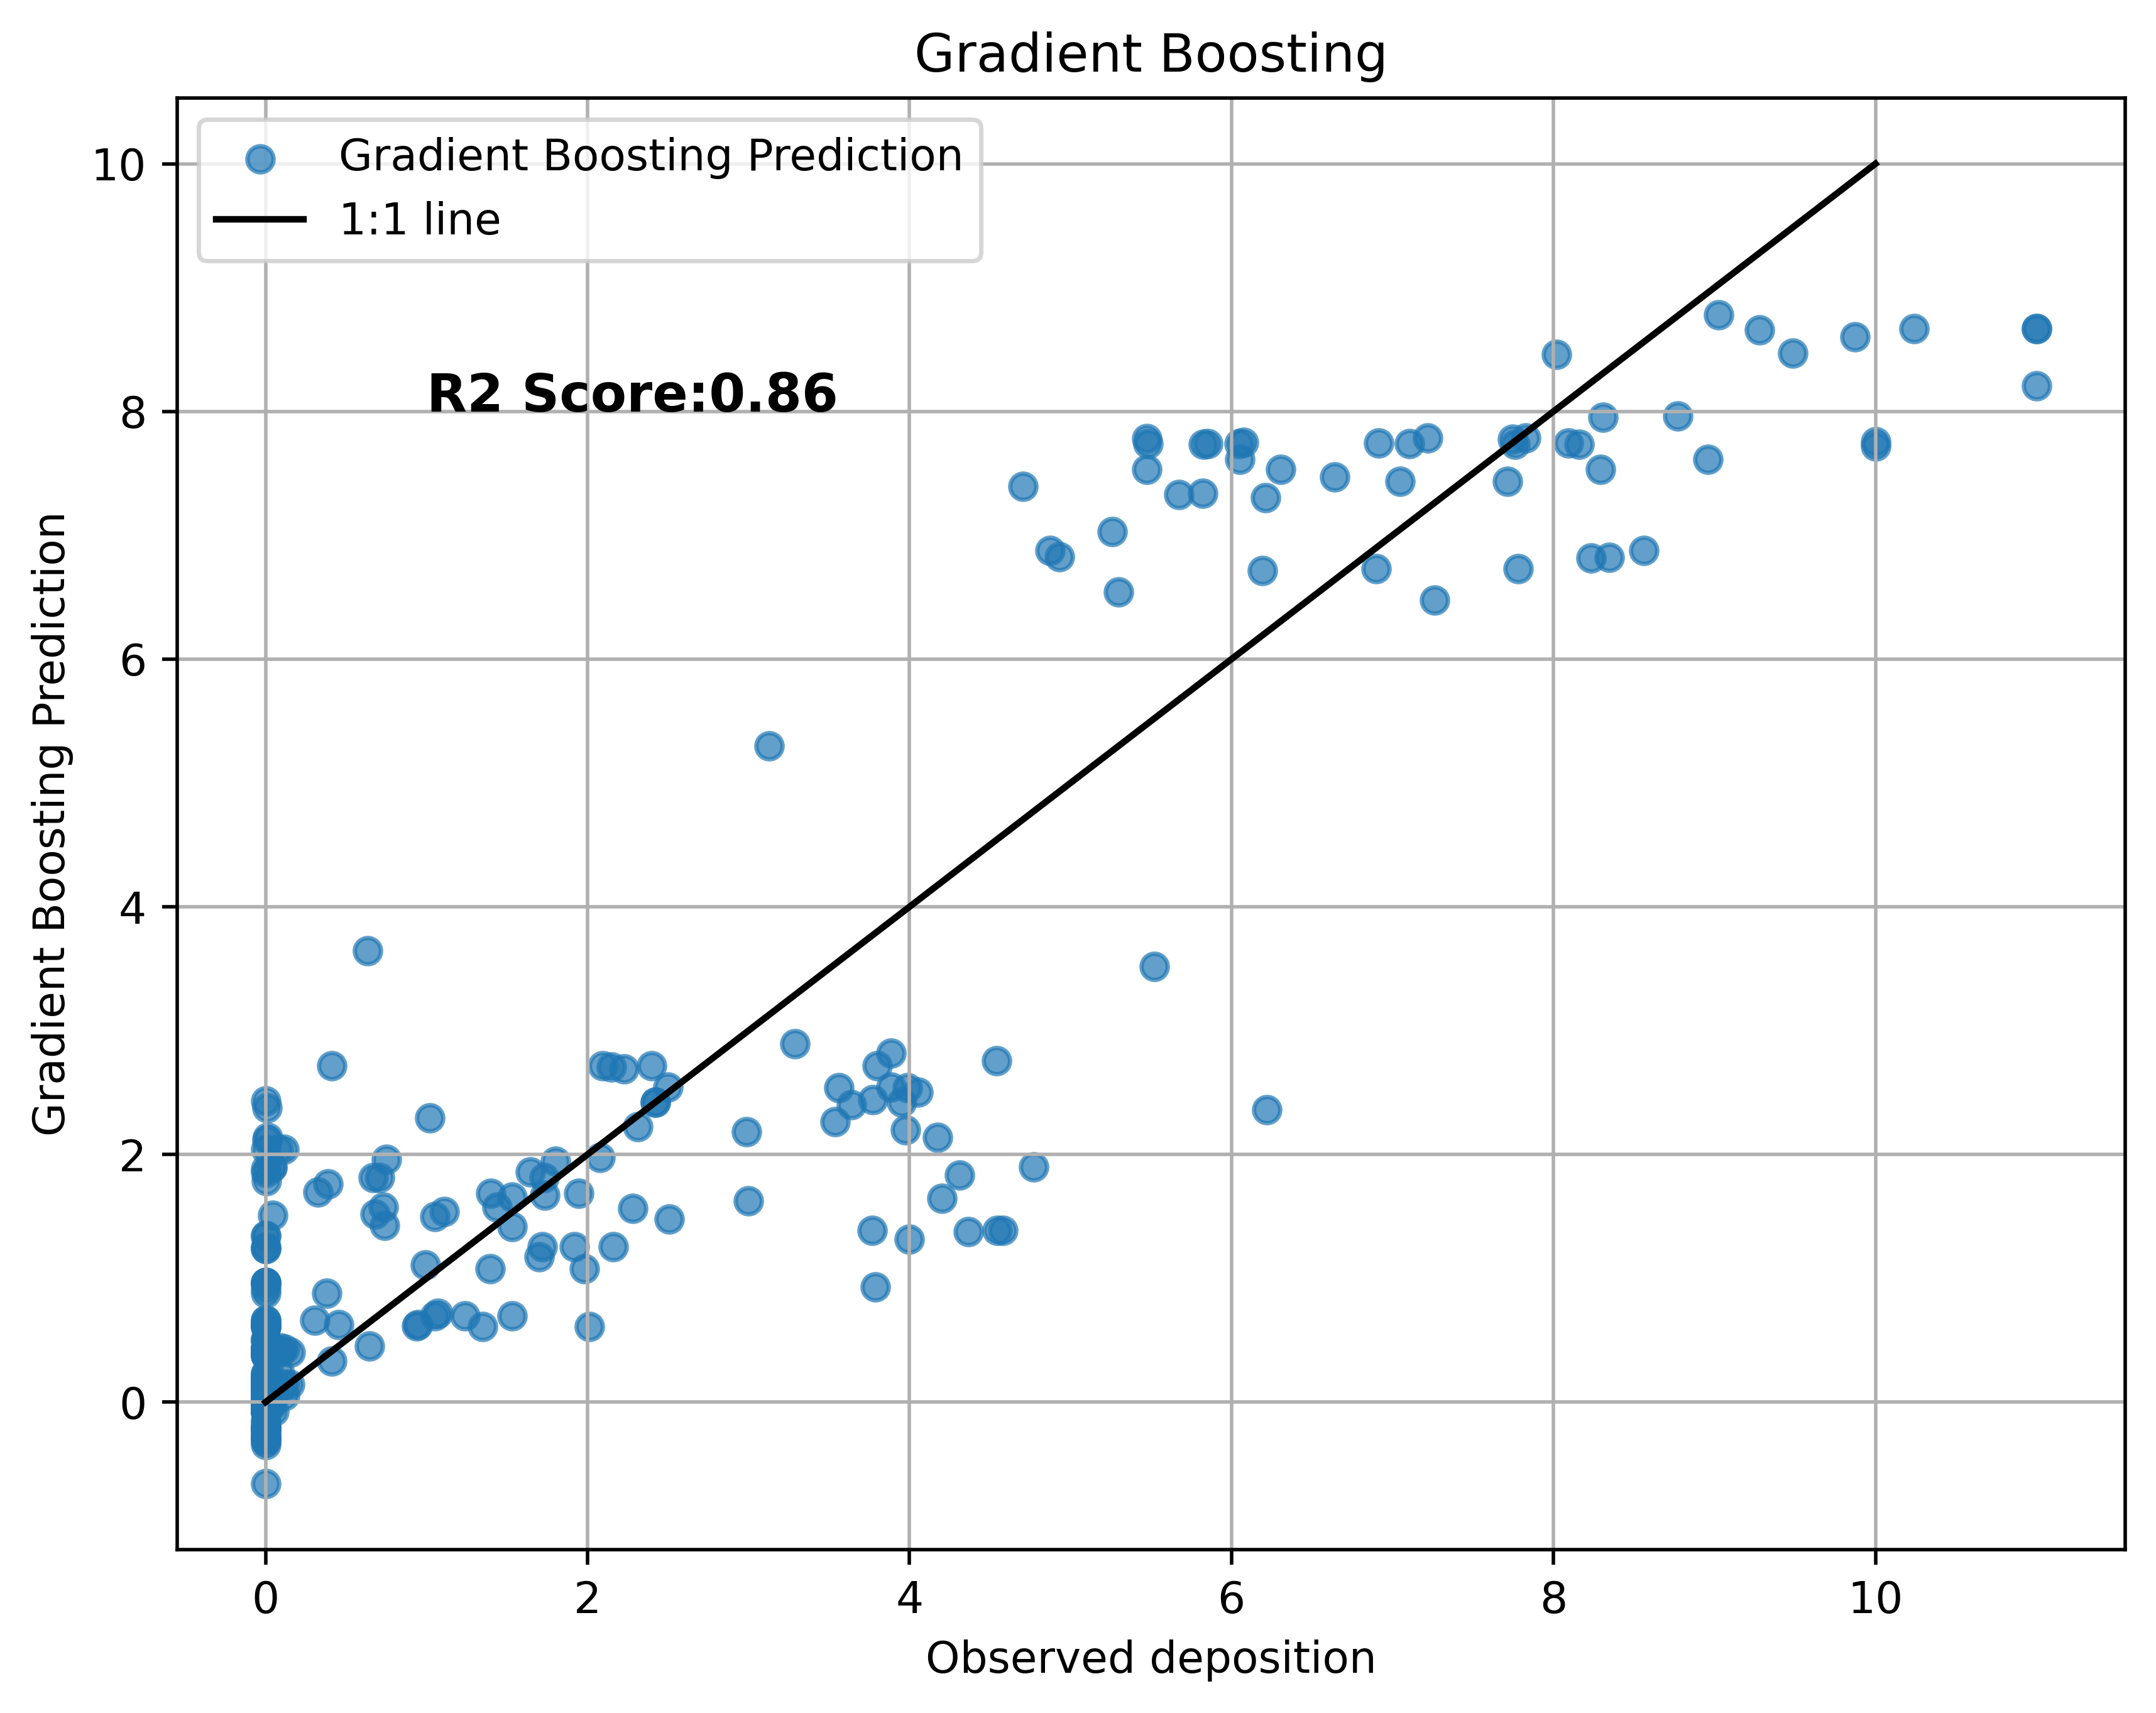

HistGradientBoosting_Regression :
MSE: 1.1047
MAE: 0.6563
Score: 0.8669


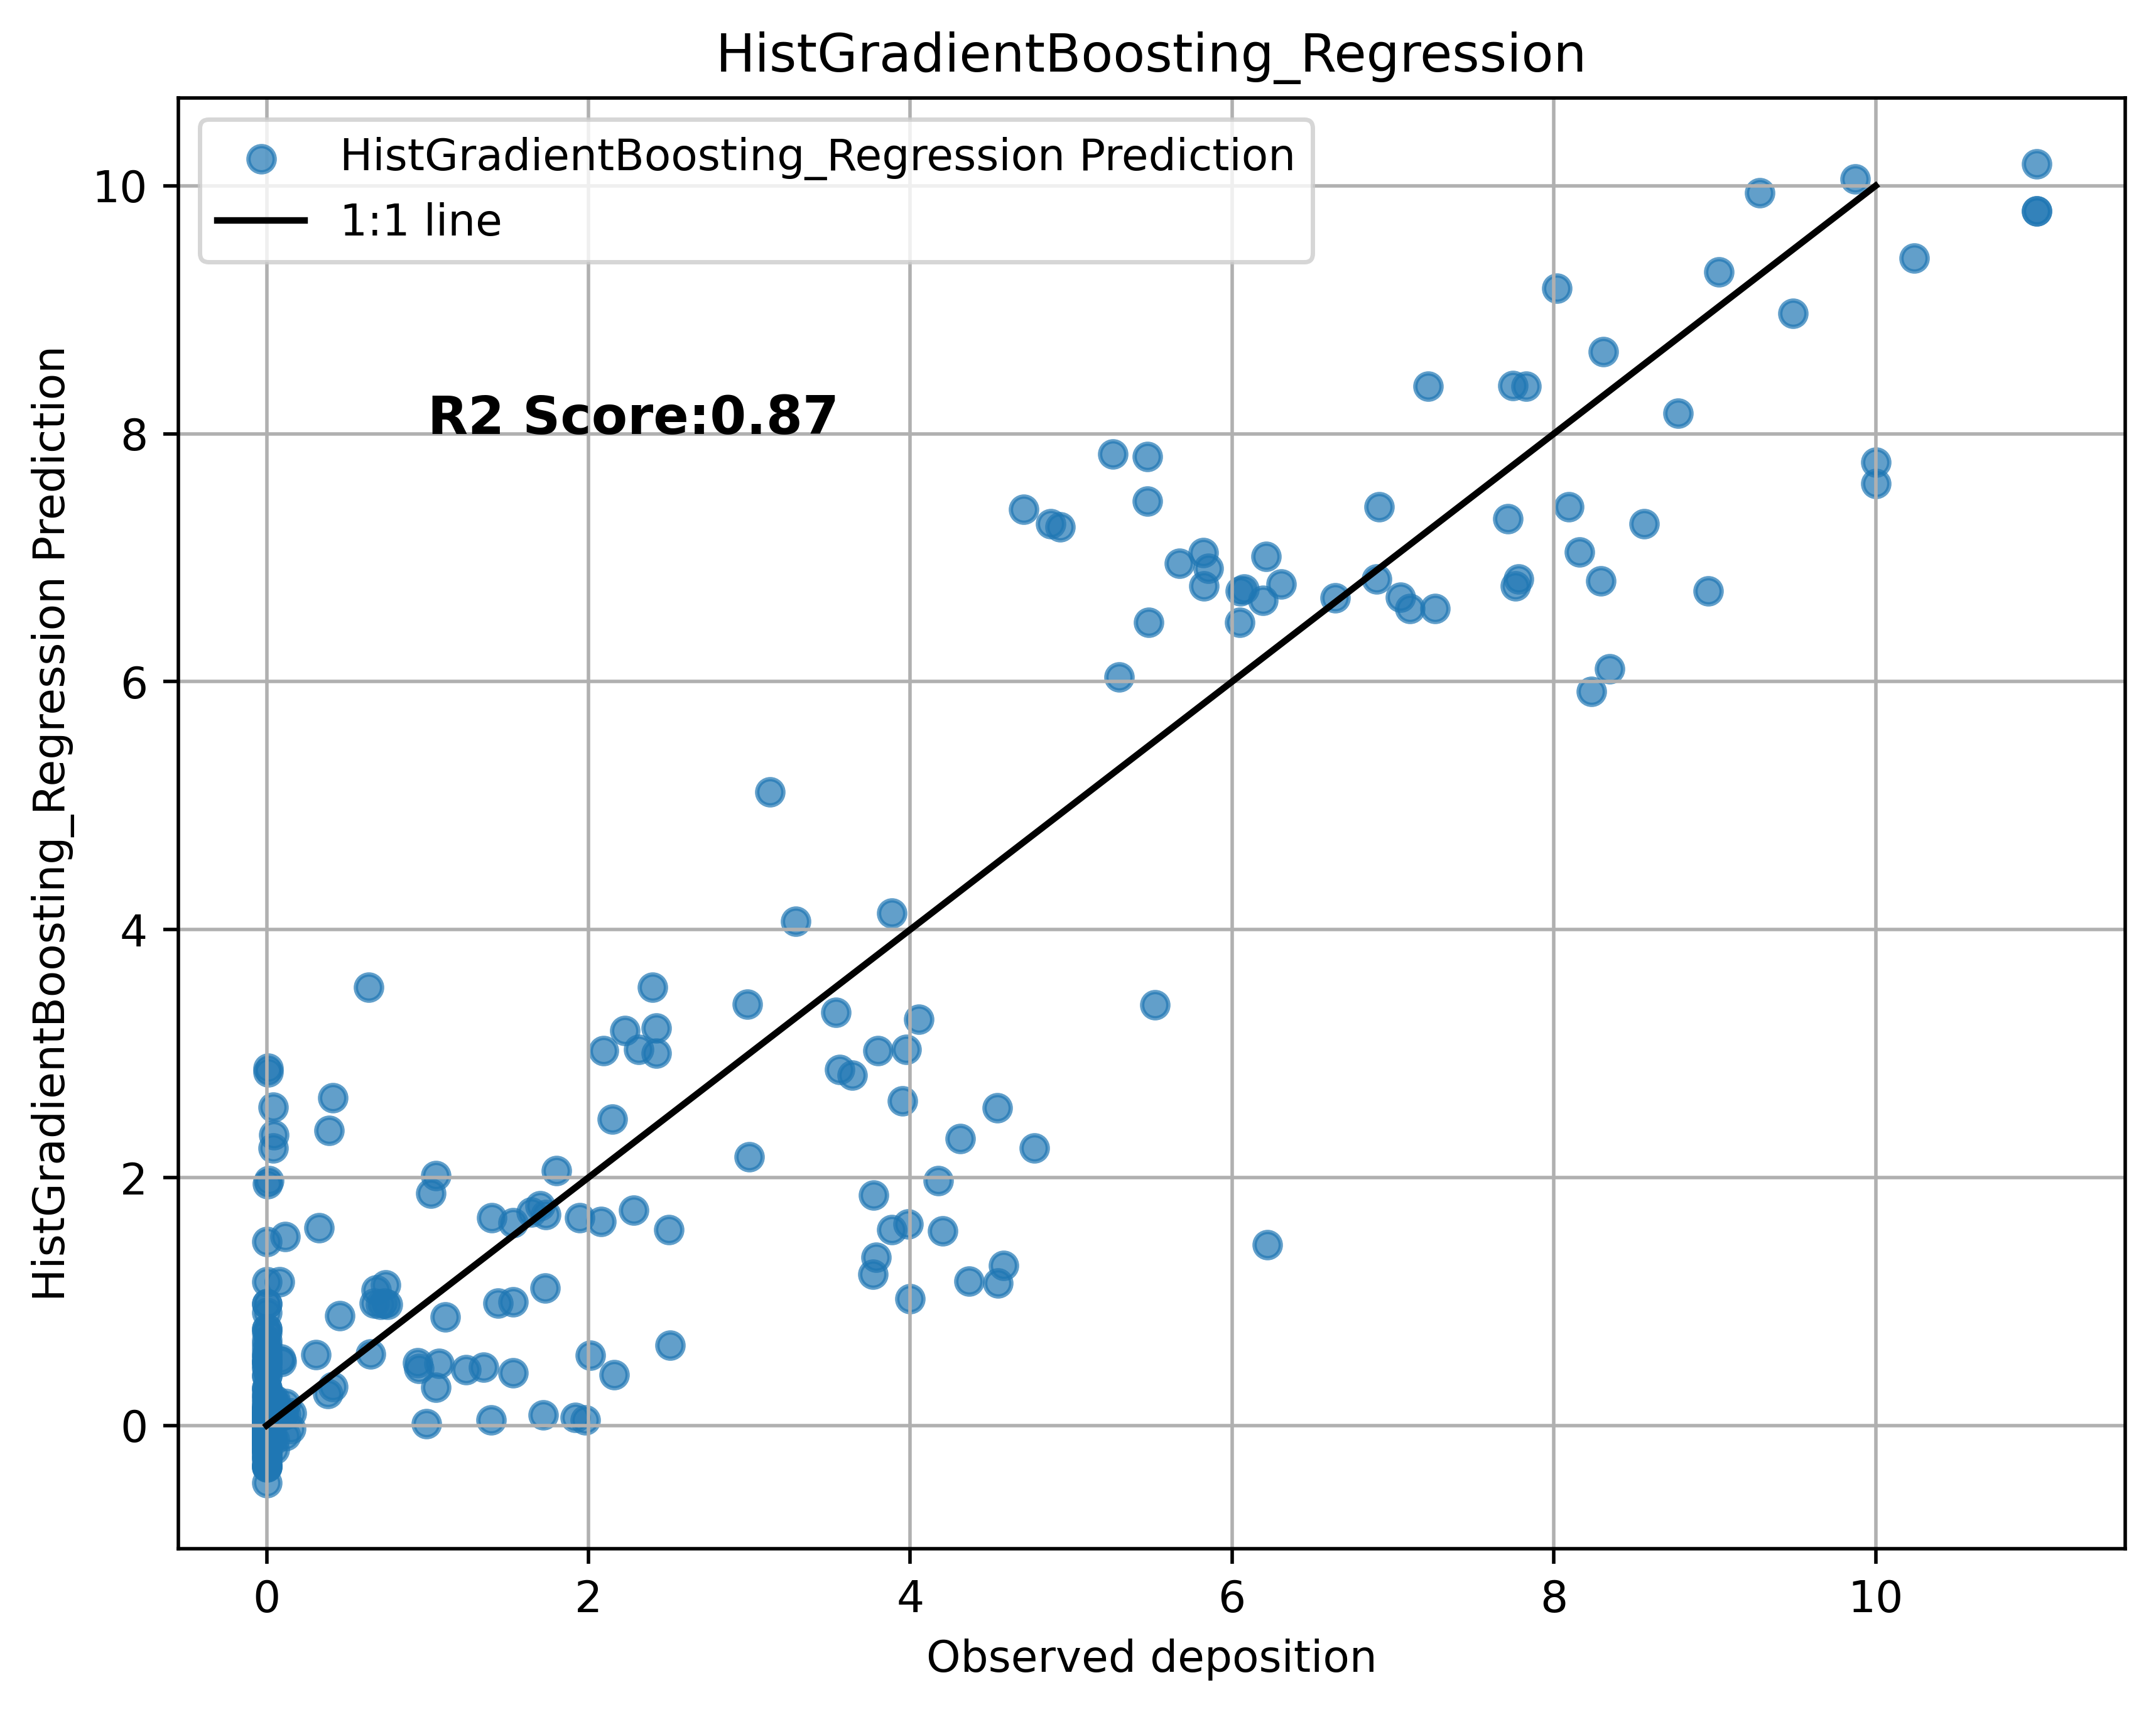

Random Forest :
MSE: 1.452
MAE: 0.6656
Score: 0.8251


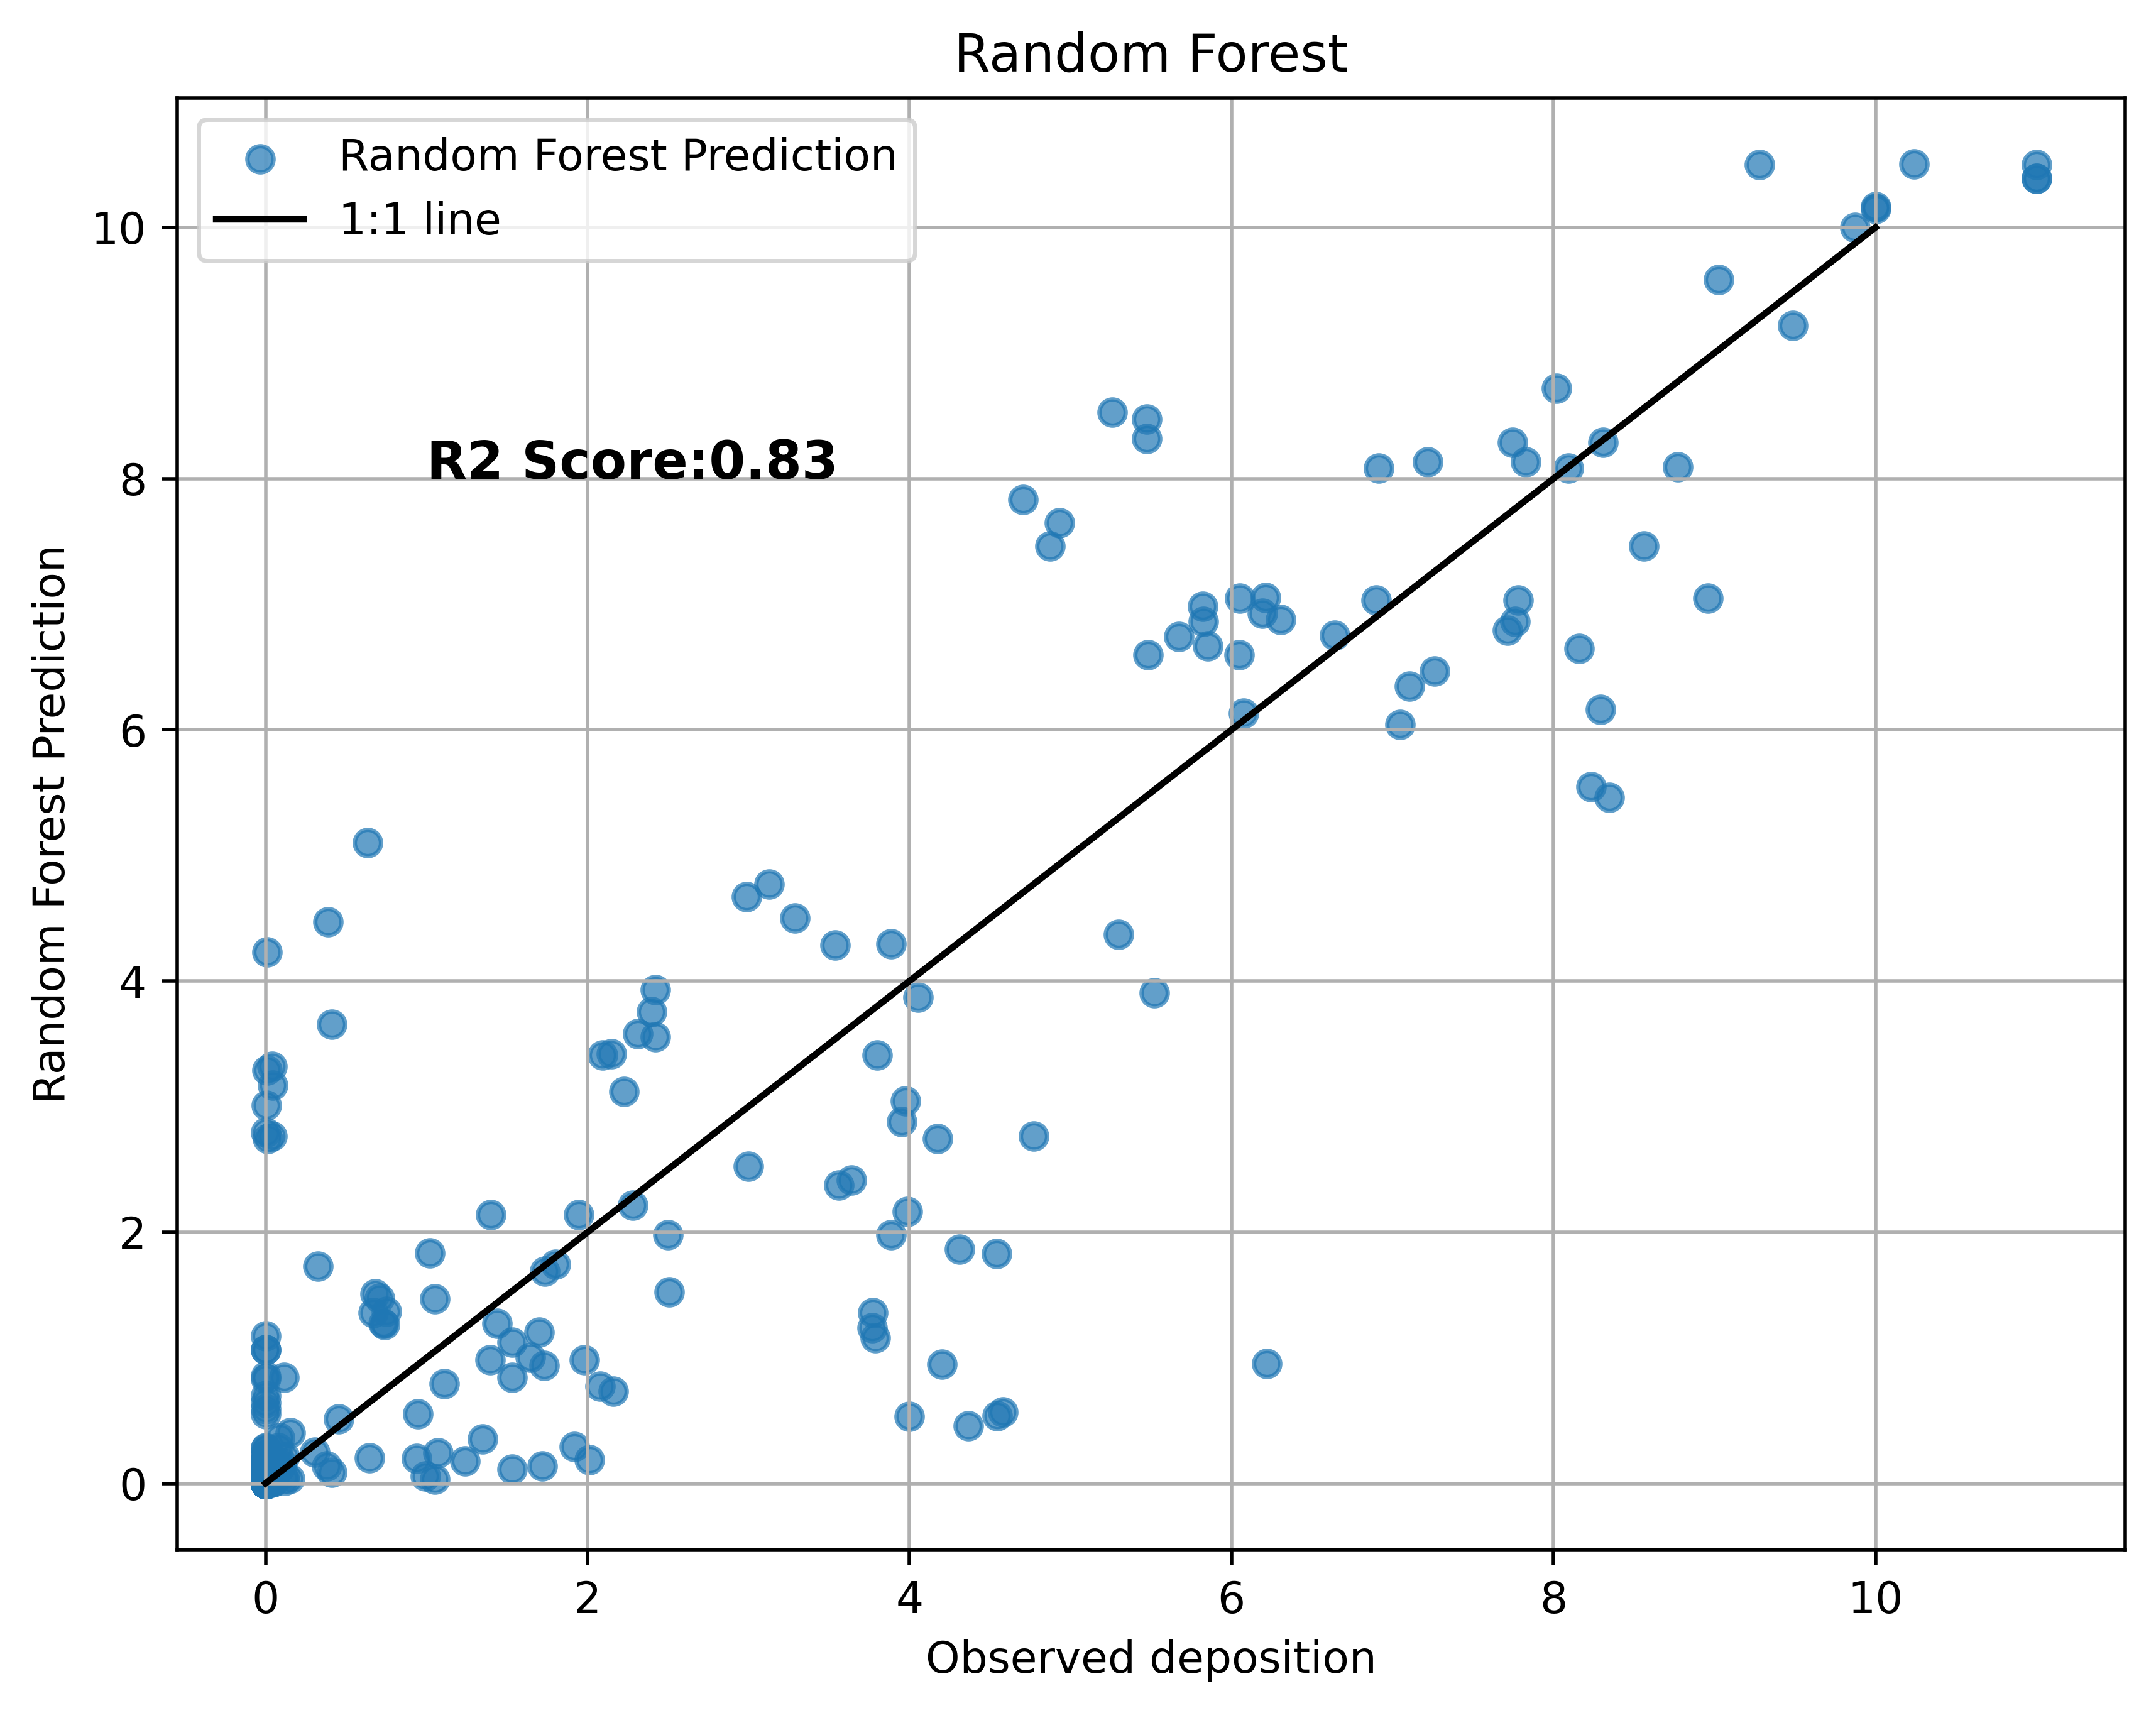

In [10]:
df_5Y_melt = df_5Y_melt.rename(columns={"variable":"diameter"})
df_5Y_melt = df_5Y_melt.rename(columns={"name":"region in nose"})

df_5Y_melt['region in nose']=df_5Y_melt['region in nose'].astype('float64')
df_5Y_melt['diameter']=df_5Y_melt['diameter'].astype('float64')


X=df_5Y_melt.loc[:,['Flow Rate[L/min]', 'region in nose', 'diameter','Velocity','Half Cone angle']]
Y =df_5Y_melt.loc[:,'Dose']

from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import cross_validate,cross_val_score, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression,Lasso,Lars,LassoLars,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import numpy as np
import matplotlib.pyplot as plt

xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.25,random_state=120)

algorithms = {
     #'Linear Regression': LinearRegression(),
     #'Lasso Regression': Lasso(),
     #'Lars Regression': Lars(),
     #'Lasso Lars Regression': LassoLars(),
     #'ElasticNet Regression': ElasticNet(),
     #'KNN-U Regression': KNeighborsRegressor(n_neighbors=5, weights='uniform'),
     #'KNN_D  Regression': KNeighborsRegressor(n_neighbors=5, weights='distance'),
     #'SVR Regression': SVR(kernel='rbf'),
     'Gradient Boosting': GradientBoostingRegressor(random_state=120),
     'HistGradientBoosting_Regression': HistGradientBoostingRegressor(),
     'Random Forest': RandomForestRegressor(random_state=120),
     #'MLP Regression': MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20)),
}

for alg in algorithms:

    print(alg,':')
    
    algorithms[alg].fit(xtrain,ytrain)
    ypred=algorithms[alg].predict(xtest)

    scores = cross_validate(algorithms[alg], xtrain,ytrain, cv=KFold(n_splits=5, shuffle=True),
                            scoring=('r2', 'neg_mean_squared_error','neg_mean_absolute_error'),return_train_score=True)

    print('MSE:',round(mean_squared_error(ytest,ypred),4))
    print('MAE:',round(mean_absolute_error(ytest,ypred),4))
    print('Score:',round(r2_score(ytest,ypred),4))
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6), dpi = 500)
    plt.scatter(ytest, ypred, alpha=0.7, label=f'{alg} Prediction')
    x_coordinates = [0, 10]
    y_coordinates = [0, 10]
#     plt.plot(x_coordinates, y_coordinates, c='black')
    plt.plot(x_coordinates, y_coordinates, c='black', label='1:1 line')
    plt.text(1,8, f'R2 Score:{round(r2_score(ytest,ypred),2)}', fontsize=12, fontweight='bold')
    plt.xlabel('Observed deposition')
    plt.ylabel(f'{alg} Prediction')
    plt.title(f'{alg}')
    plt.legend()
    plt.grid(True)
#     plt.savefig('Linear Regression_DPM_Case19.jpeg', dpi =300)
    plt.show()


Gradient Boosting with Hyperparameter Tuning:
Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 400}
MSE: 1.0231
MAE: 0.6238
R2 Score: 0.8768


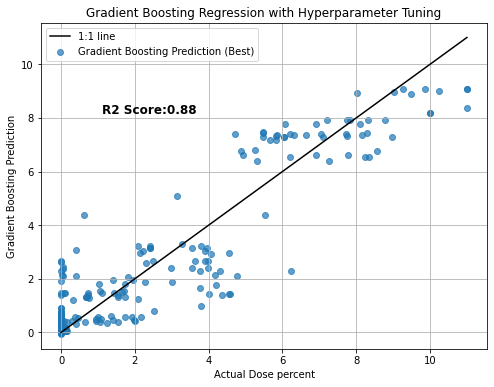

In [8]:
gb_regressor = GradientBoostingRegressor(random_state=120)

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(gb_regressor, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(xtrain, ytrain)

best_gb_regressor = grid_search.best_estimator_

ypred_best = best_gb_regressor.predict(xtest)

mse_best = mean_squared_error(ytest, ypred_best)
mae_best = mean_absolute_error(ytest, ypred_best)
r2_best = r2_score(ytest, ypred_best)

print('Gradient Boosting with Hyperparameter Tuning:')
print('Best Parameters:', grid_search.best_params_)
print('MSE:', round(mse_best, 4))
print('MAE:', round(mae_best, 4))
print('R2 Score:', round(r2_best, 4))

plt.figure(figsize=(8, 6))
plt.scatter(ytest, ypred_best, alpha=0.7, label='Gradient Boosting Prediction (Best)')
plt.plot([0, np.max(ytest)], [0, np.max(ytest)], c='black', label='1:1 line')
plt.text(np.max(ytest) * 0.1, np.max(ypred_best) * 0.9, f'R2 Score:{round(r2_best, 2)}', fontsize=12, fontweight='bold')
plt.xlabel('Actual Dose percent')
plt.ylabel('Gradient Boosting Prediction')
plt.title('Gradient Boosting Regression with Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestR

RandomForestRegressor with Hyperparameter Tuning:
Best Parameters: {'max_depth': 10, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
MSE: 1.0276
MAE: 0.598
R2 Score: 0.8762


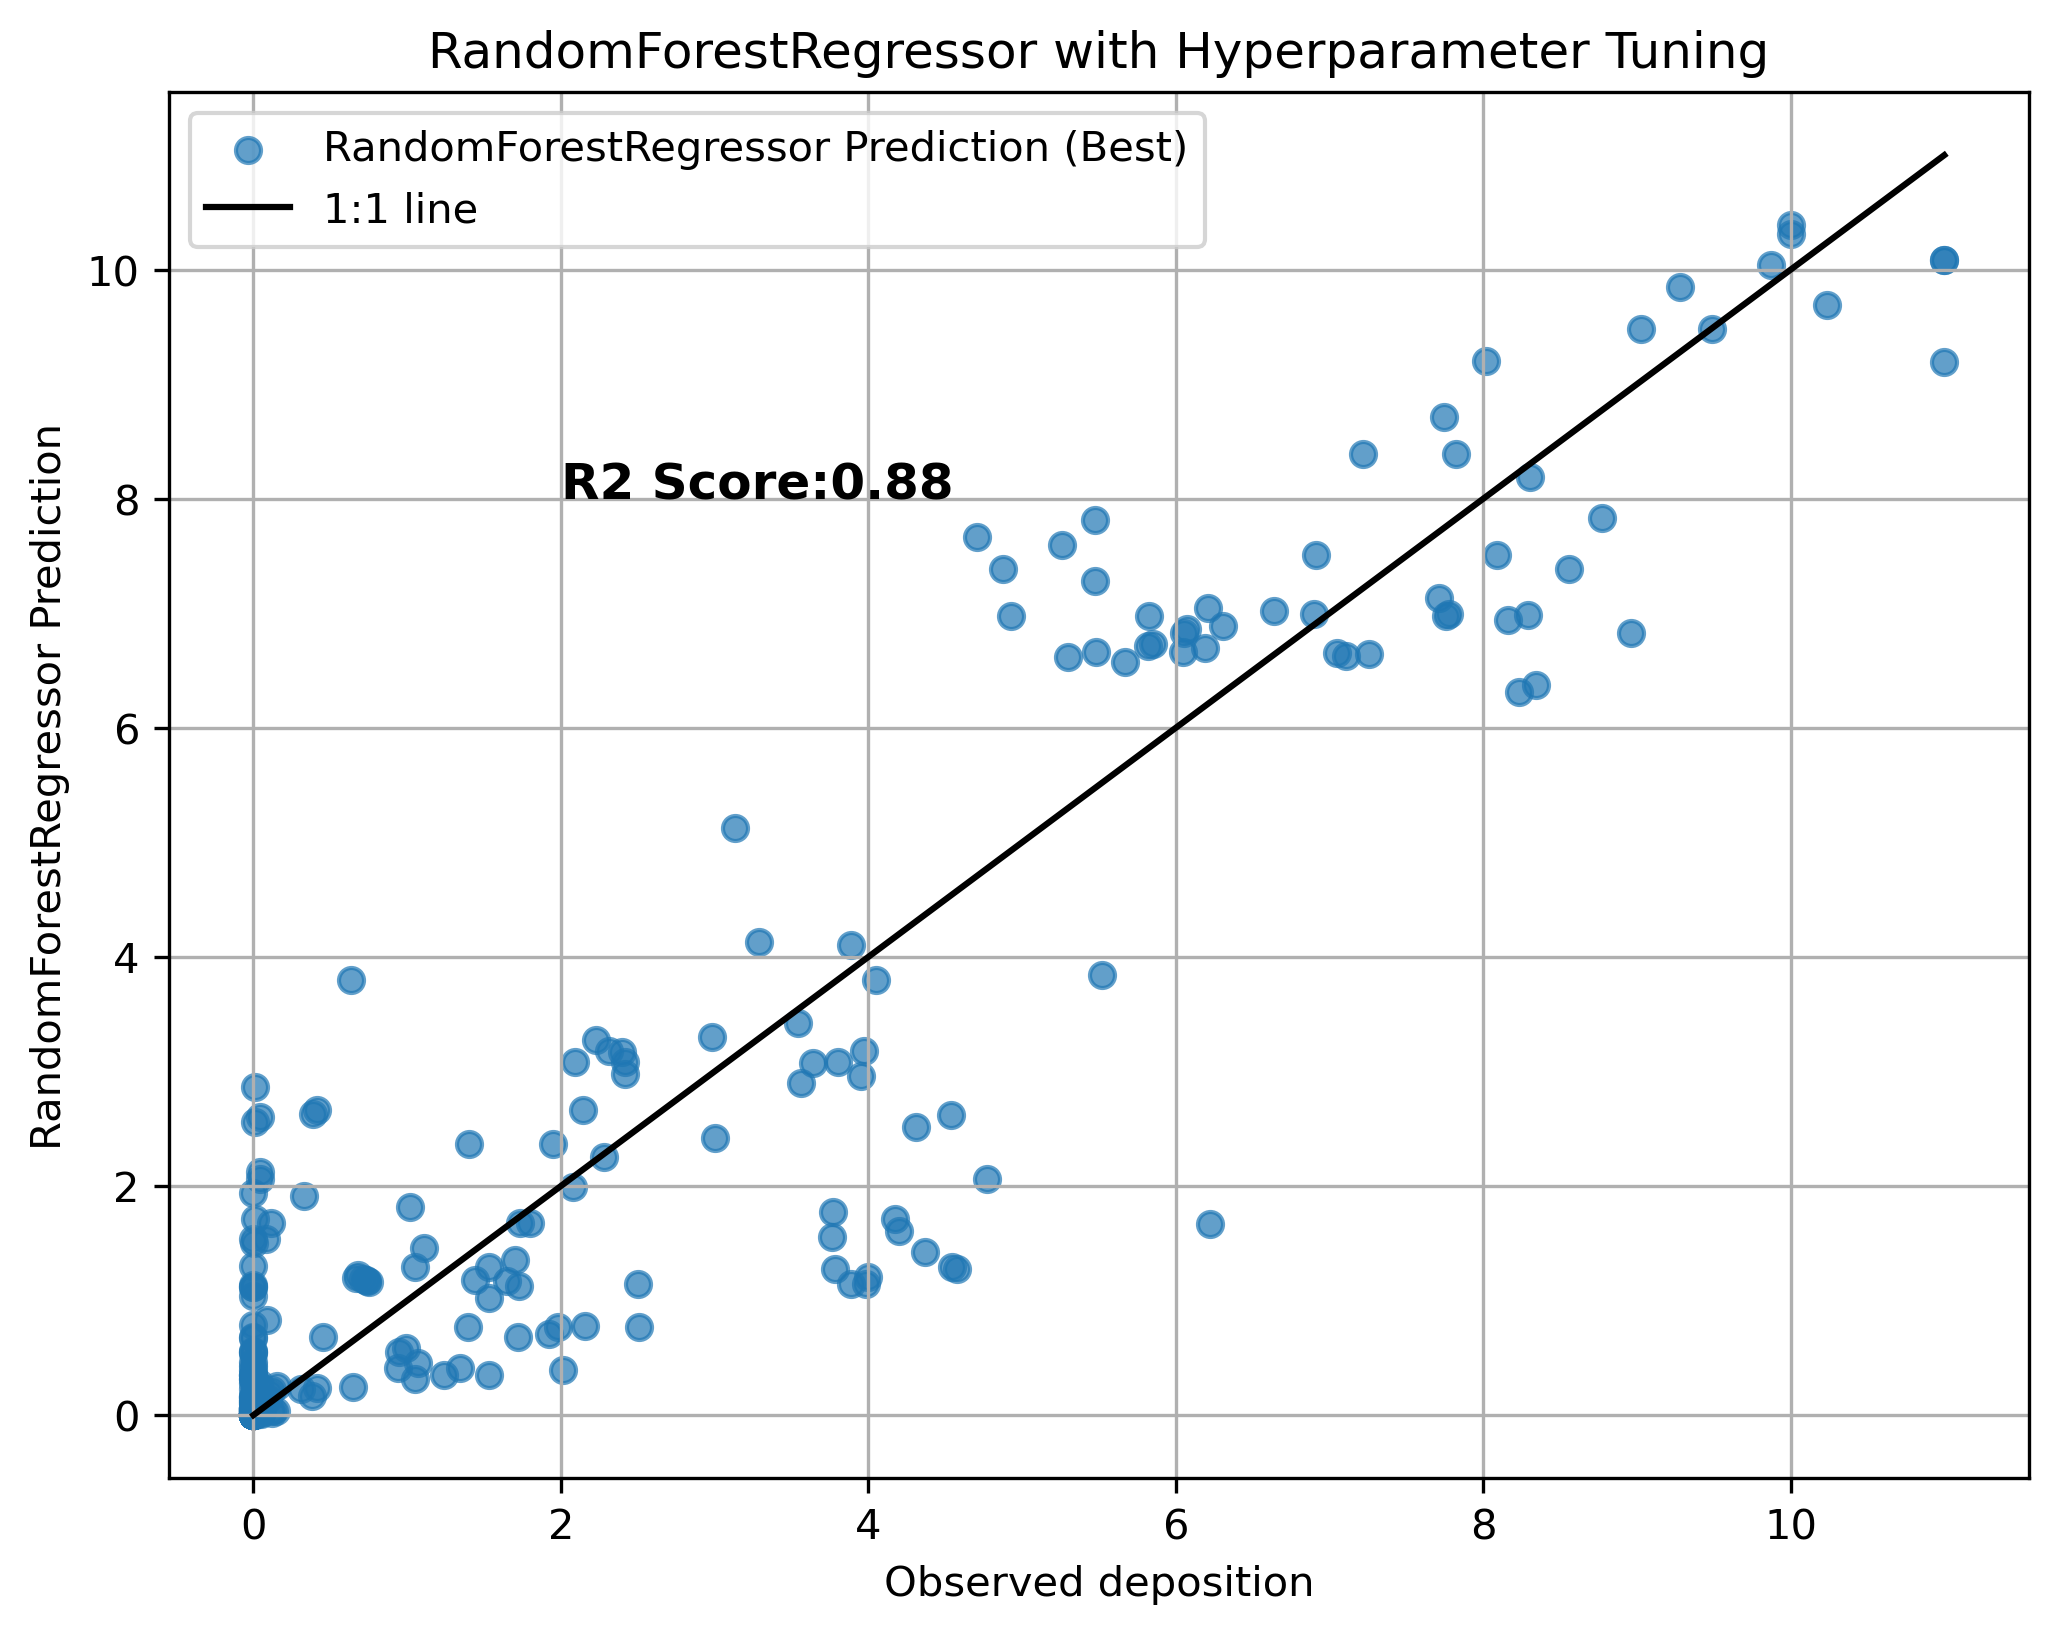

In [11]:
# Hyperparameter tuning for RandomForestRegressor
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf_regressor = RandomForestRegressor(random_state=120)

grid_search = GridSearchCV(rf_regressor, param_grid, cv=5, scoring='r2')
grid_search.fit(xtrain, ytrain)

best_rf_regressor = grid_search.best_estimator_

ypred_best = best_rf_regressor.predict(xtest)

mse_best = mean_squared_error(ytest, ypred_best)
mae_best = mean_absolute_error(ytest, ypred_best)
r2_best = r2_score(ytest, ypred_best)

print('RandomForestRegressor with Hyperparameter Tuning:')
print('Best Parameters:', grid_search.best_params_)
print('MSE:', round(mse_best, 4))
print('MAE:', round(mae_best, 4))
print('R2 Score:', round(r2_best, 4))

plt.figure(figsize=(8, 6),dpi=300)
plt.scatter(ytest, ypred_best, alpha=0.7, label='RandomForestRegressor Prediction (Best)')
plt.plot([0, np.max(ytest)], [0, np.max(ytest)], c='black', label='1:1 line')
plt.text(2, 8, f'R2 Score:{round(r2_best, 2)}', fontsize=12, fontweight='bold')
plt.xlabel('Observed deposition')
plt.ylabel('RandomForestRegressor Prediction')
plt.title('RandomForestRegressor with Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()


HistGradientBoostingRegressor with Hyperparameter Tuning:
Best Parameters: {'l2_regularization': 0, 'learning_rate': 0.2, 'max_depth': 3, 'max_iter': 100, 'min_samples_leaf': 1}
MSE: 1.0798
MAE: 0.6753
R2 Score: 0.8699


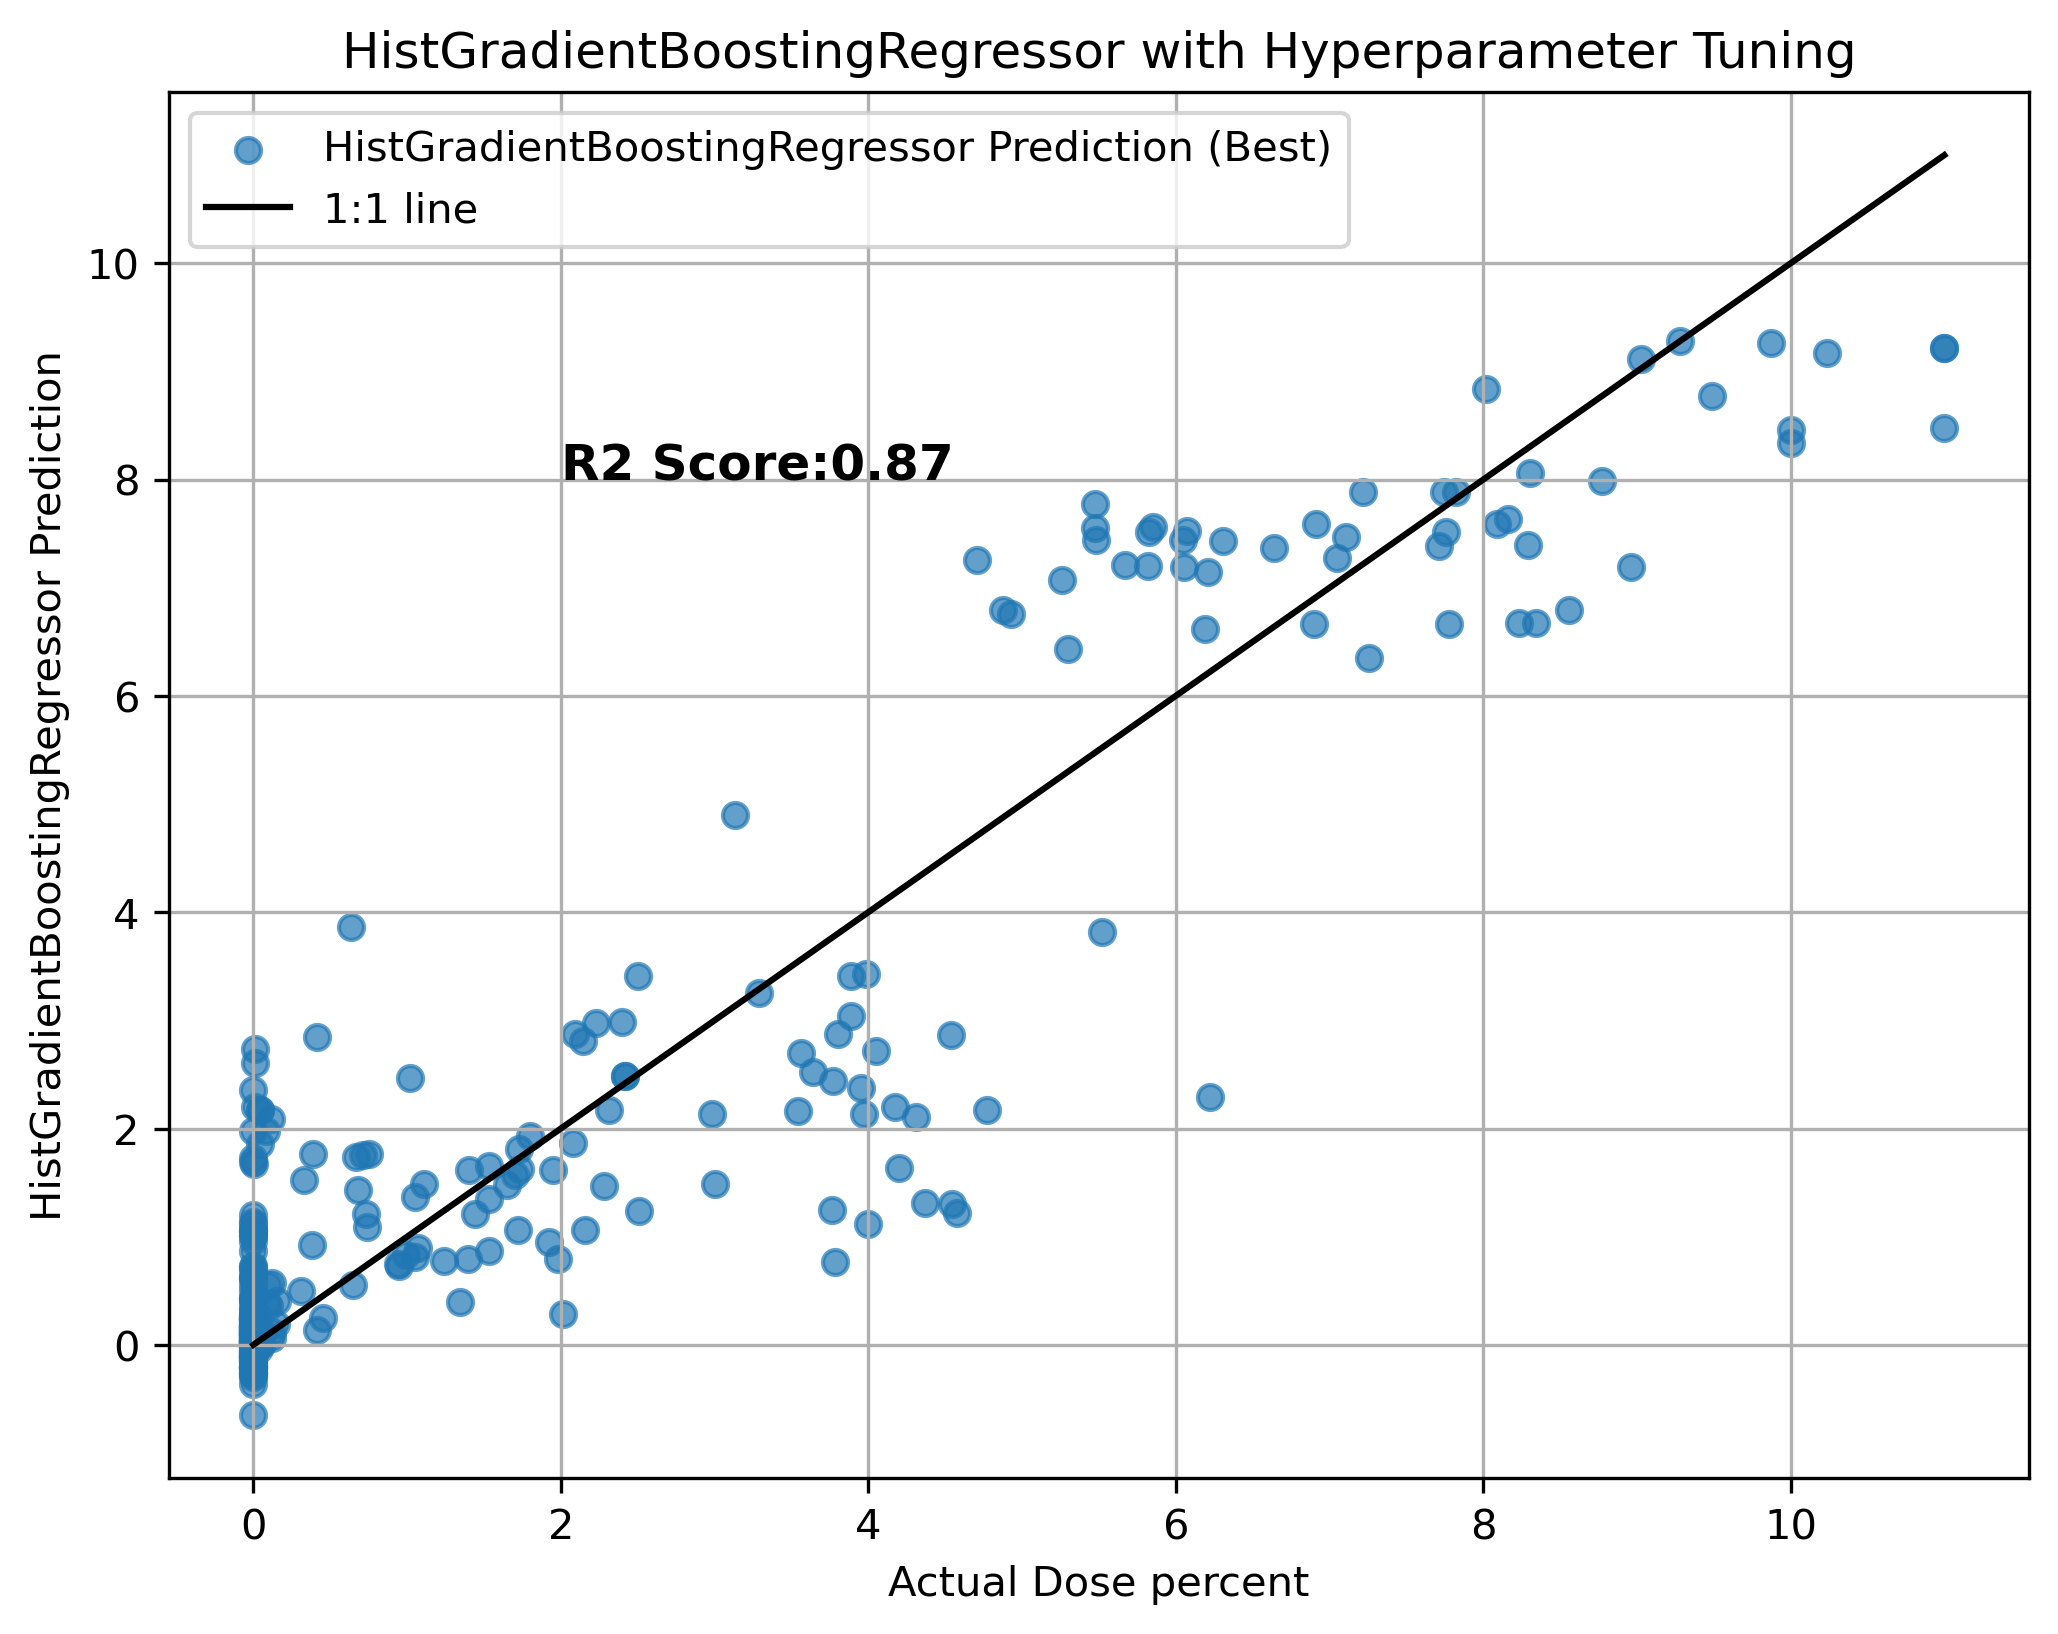

In [12]:
# Hyperparameter tuning for HistGradientBoostingRegressor
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'max_iter': [100],
    'min_samples_leaf': [1, 2, 4],
    'l2_regularization': [0, 0.1, 0.5]
}

hgb_regressor = HistGradientBoostingRegressor(random_state=120)

grid_search = GridSearchCV(hgb_regressor, param_grid, cv=5, scoring='r2')
grid_search.fit(xtrain, ytrain)

best_hgb_regressor = grid_search.best_estimator_

ypred_best = best_hgb_regressor.predict(xtest)

mse_best = mean_squared_error(ytest, ypred_best)
mae_best = mean_absolute_error(ytest, ypred_best)
r2_best = r2_score(ytest, ypred_best)

print('HistGradientBoostingRegressor with Hyperparameter Tuning:')
print('Best Parameters:', grid_search.best_params_)
print('MSE:', round(mse_best, 4))
print('MAE:', round(mae_best, 4))
print('R2 Score:', round(r2_best, 4))

# Create a scatter plot
plt.figure(figsize=(8, 6),dpi=300)
plt.scatter(ytest, ypred_best, alpha=0.7, label='HistGradientBoostingRegressor Prediction (Best)')
plt.plot([0, np.max(ytest)], [0, np.max(ytest)], c='black', label='1:1 line')
plt.text(2, 8, f'R2 Score:{round(r2_best, 2)}', fontsize=12, fontweight='bold')
plt.xlabel('Actual Dose percent')
plt.ylabel('HistGradientBoostingRegressor Prediction')
plt.title('HistGradientBoostingRegressor with Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()


## Case: 6 years old-CF

In [13]:
df_6Y = pd.read_excel("Case6Y_DPM.xlsx")
df_6Y

,10,20,30,40,50,60,70,80,90,100,Flow Rate[L/min],Velocity,Half Cone angle,region,name
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8.7,19.2,16.0,Vestibule,0
1,2.20,8.00,9.20,8.40,8.12,9.20,8.30,9.30,8.40,9.21,8.7,19.2,16.0,Nasal Valve,1
2,0.48,1.91,1.76,1.56,1.88,1.76,1.64,1.66,1.51,1.78,8.7,19.2,16.0,Anterior Turbinate,2
3,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8.7,19.2,16.0,Nasopharynx,3
4,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8.7,19.2,16.0,Outlet,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,15.0,2.0,39.5,Vestibule,0
116,0.00,0.00,0.69,1.47,2.21,2.60,2.72,3.01,2.78,3.13,15.0,2.0,39.5,Nasal Valve,1
117,5.18,10.00,10.30,8.52,7.78,8.40,7.28,8.00,7.22,7.86,15.0,2.0,39.5,Anterior Turbinate,2
118,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,15.0,2.0,39.5,Nasopharynx,3


In [17]:
df_6Y_melt=pd.melt(df_6Y,id_vars=['Flow Rate[L/min]','region', 'name', 'Velocity','Half Cone angle'],
           value_vars=[10,20,30,40,50,60,70,80,90,100],
           value_name='Dose')
df_6Y_melt

,Flow Rate[L/min],region,name,Velocity,Half Cone angle,variable,Dose
0,8.7,Vestibule,0,19.2,16.0,10,0.00
1,8.7,Nasal Valve,1,19.2,16.0,10,2.20
2,8.7,Anterior Turbinate,2,19.2,16.0,10,0.48
3,8.7,Nasopharynx,3,19.2,16.0,10,0.32
4,8.7,Outlet,4,19.2,16.0,10,3.00
...,...,...,...,...,...,...,...
1195,15.0,Vestibule,0,2.0,39.5,100,0.00
1196,15.0,Nasal Valve,1,2.0,39.5,100,3.13
1197,15.0,Anterior Turbinate,2,2.0,39.5,100,7.86
1198,15.0,Nasopharynx,3,2.0,39.5,100,0.00


C:\Users\DFMRendering\AppData\Local\Temp\ipykernel_15744\872810328.py:7: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.swarmplot(x="region", y="Dose", data=df_6Y_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 86.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 87.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\li

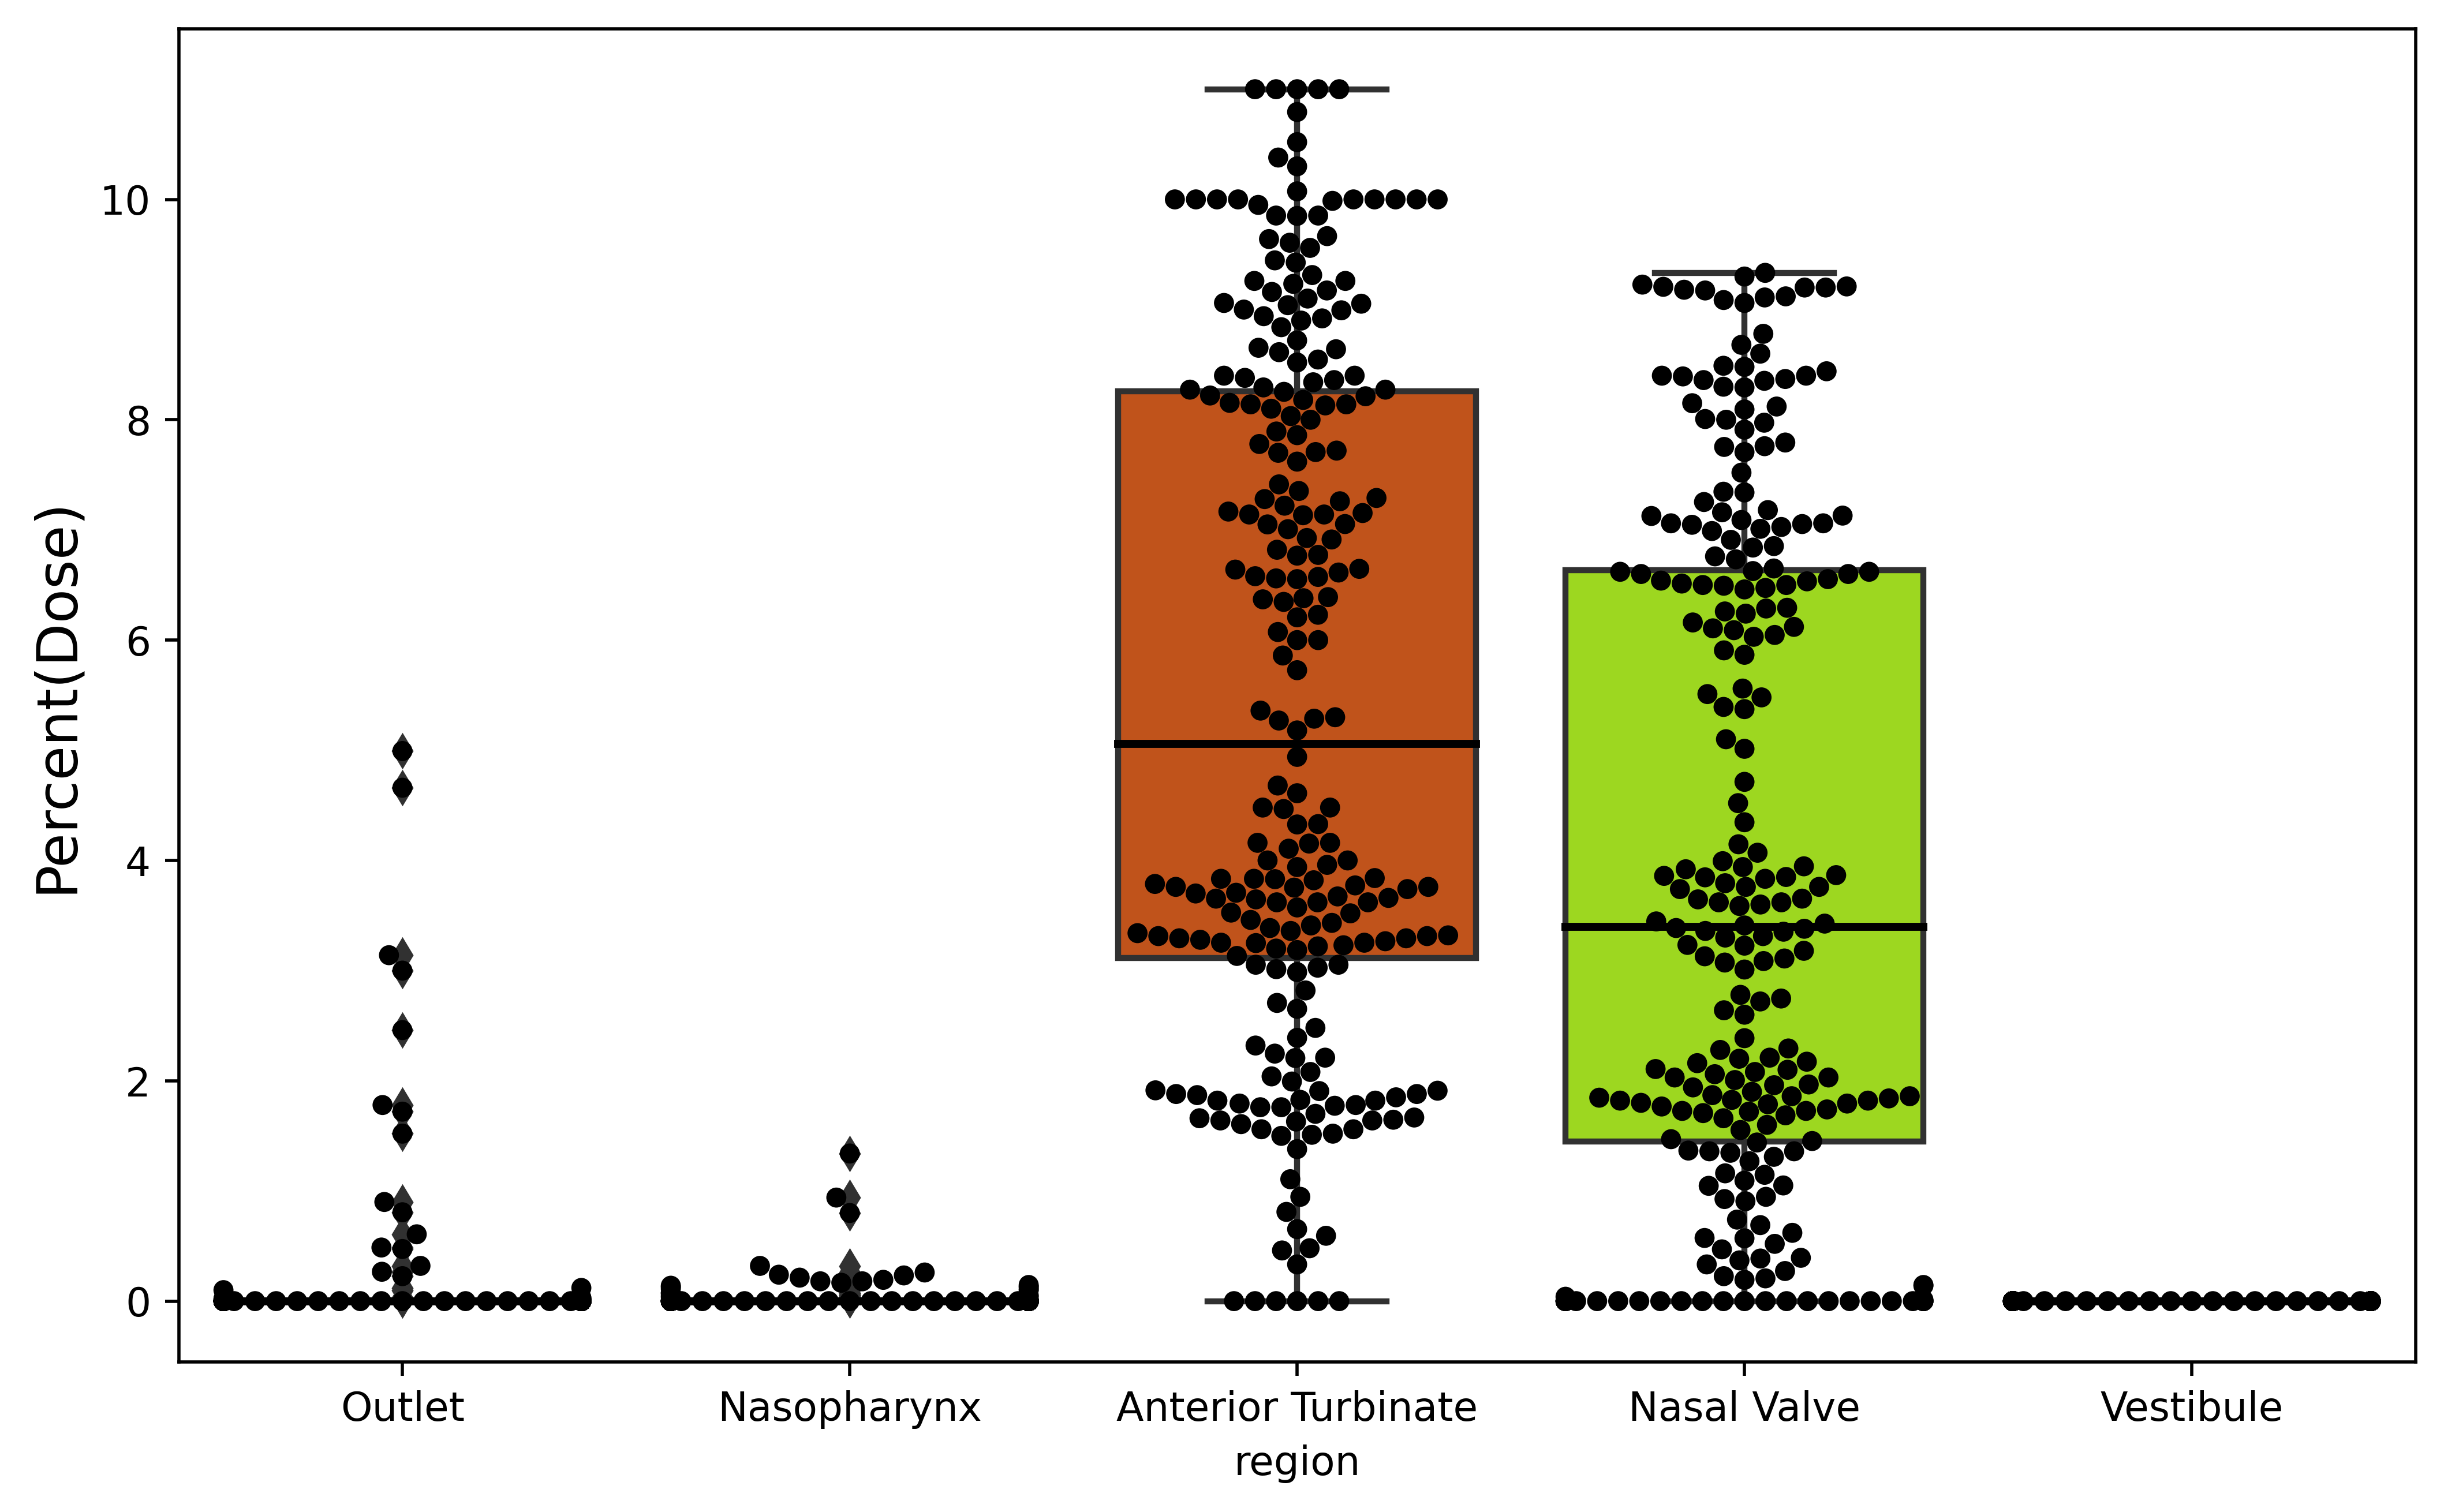

In [18]:
my_pal = {"Vestibule": "#24247e", "Nasal Valve": "#9dd720", "Anterior Turbinate":"#c0531b", "Nasopharynx":"#b61b1c","Outlet":"#DC143C"}
my_pal_2 = {"Vestibule": "black", "Nasal Valve": "black", "Anterior Turbinate":"black", "Nasopharynx":"black", "Outlet":"black"}
medianprops = dict(linestyle='-', linewidth=2, color='black')
plt.figure(figsize=(10,6), dpi = 500)

ax = sns.boxplot(x="region", y="Dose", data=df_6Y_melt, palette=my_pal, saturation=100, medianprops=medianprops, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
ax = sns.swarmplot(x="region", y="Dose", data=df_6Y_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
plt.ylabel('Percent(Dose)', fontsize= 14)

plt.show()

Random Forest :
MSE: 5.7698
MAE: 1.3396
Score: 0.3382


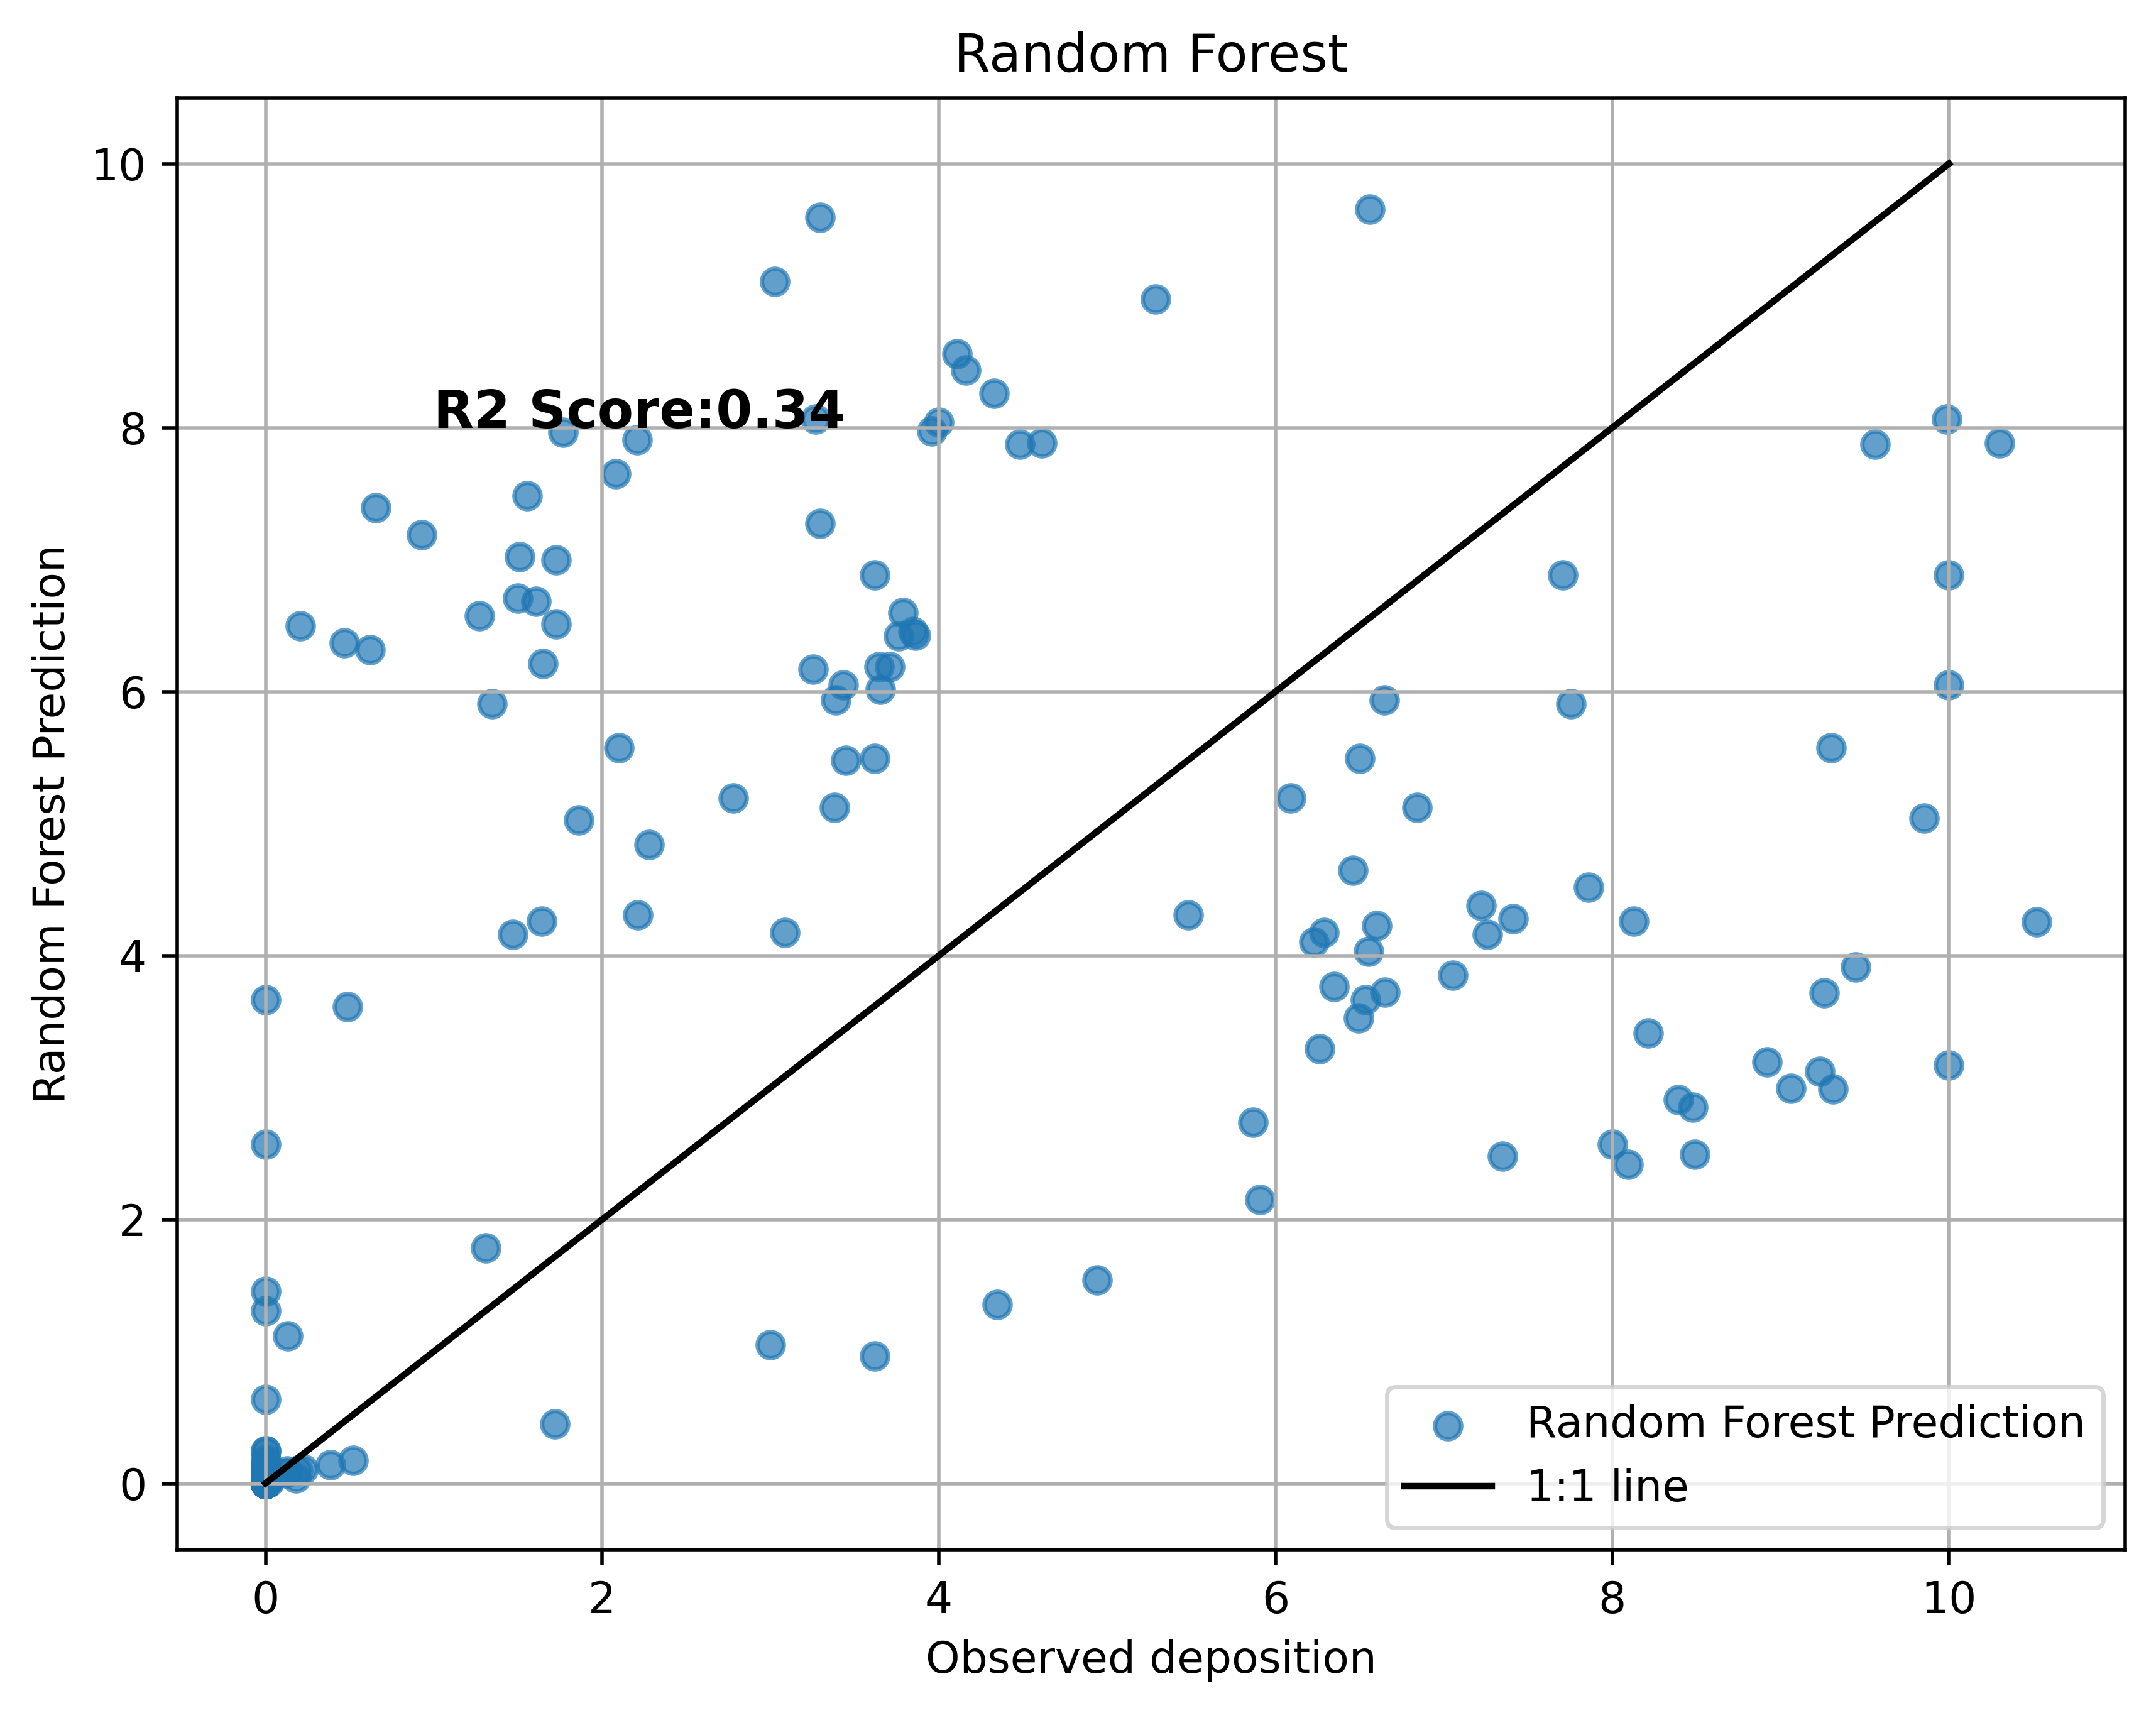

In [19]:
df_6Y_melt = df_6Y_melt.rename(columns={"variable":"diameter"})
df_6Y_melt = df_6Y_melt.rename(columns={"name":"region in nose"})

df_6Y_melt['region in nose']=df_6Y_melt['region in nose'].astype('float64')
df_6Y_melt['diameter']=df_6Y_melt['diameter'].astype('float64')


X=df_6Y_melt.loc[:,['Flow Rate[L/min]', 'region in nose', 'diameter','Velocity','Half Cone angle']]
Y =df_6Y_melt.loc[:,'Dose']

from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.model_selection import cross_validate,cross_val_score, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression,Lasso,Lars,LassoLars,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import numpy as np
import matplotlib.pyplot as plt

xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.25,random_state=120)

algorithms = {
     #'Linear Regression': LinearRegression(),
     #'Lasso Regression': Lasso(),
     #'Lars Regression': Lars(),
     #'Lasso Lars Regression': LassoLars(),
     #'ElasticNet Regression': ElasticNet(),
     #'KNN-U Regression': KNeighborsRegressor(n_neighbors=5, weights='uniform'),
     #'KNN_D  Regression': KNeighborsRegressor(n_neighbors=5, weights='distance'),
     #'SVR Regression': SVR(kernel='rbf'),
     #'Gradient Boosting': GradientBoostingRegressor(random_state=120),
     #'HistGradientBoosting_Regression': HistGradientBoostingRegressor(),
     'Random Forest': RandomForestRegressor(random_state=120),
     #'MLP Regression': MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20)),
}

for alg in algorithms:

    print(alg,':')
    
    algorithms[alg].fit(xtrain,ytrain)
    ypred=algorithms[alg].predict(xtest)

    scores = cross_validate(algorithms[alg], xtrain,ytrain, cv=KFold(n_splits=5, shuffle=True),
                            scoring=('r2', 'neg_mean_squared_error','neg_mean_absolute_error'),return_train_score=True)

    print('MSE:',round(mean_squared_error(ytest,ypred),4))
    print('MAE:',round(mean_absolute_error(ytest,ypred),4))
    print('Score:',round(r2_score(ytest,ypred),4))
    
    plt.figure(figsize=(8, 6), dpi = 500)
    plt.scatter(ytest, ypred, alpha=0.7, label=f'{alg} Prediction')
    x_coordinates = [0, 10]
    y_coordinates = [0, 10]
    plt.plot(x_coordinates, y_coordinates, c='black', label='1:1 line')
    plt.text(1,8, f'R2 Score:{round(r2_score(ytest,ypred),2)}', fontsize=12, fontweight='bold')
    plt.xlabel('Observed deposition')
    plt.ylabel(f'{alg} Prediction')
    plt.title(f'{alg}')
    plt.legend()
    plt.grid(True)
    plt.show()


Gradient Boosting with Hyperparameter Tuning:
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
MSE: 2.83
MAE: 1.0161
R2 Score: 0.6754


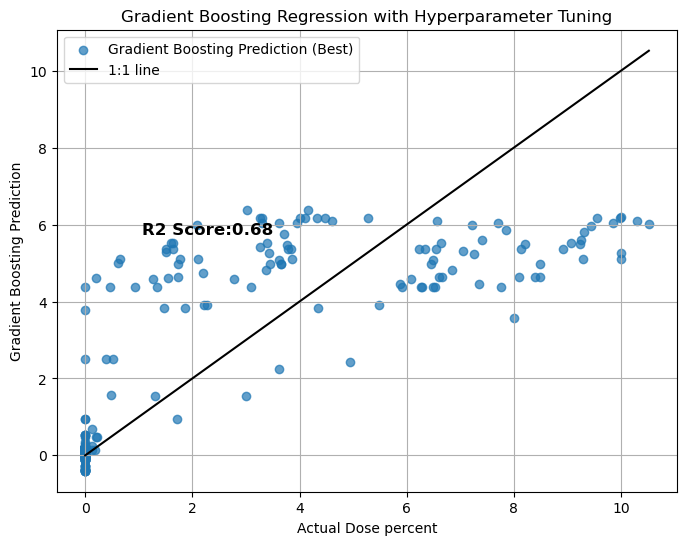

In [20]:

gb_regressor = GradientBoostingRegressor(random_state=120)
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(gb_regressor, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(xtrain, ytrain)

best_gb_regressor = grid_search.best_estimator_

ypred_best = best_gb_regressor.predict(xtest)

mse_best = mean_squared_error(ytest, ypred_best)
mae_best = mean_absolute_error(ytest, ypred_best)
r2_best = r2_score(ytest, ypred_best)

print('Gradient Boosting with Hyperparameter Tuning:')
print('Best Parameters:', grid_search.best_params_)
print('MSE:', round(mse_best, 4))
print('MAE:', round(mae_best, 4))
print('R2 Score:', round(r2_best, 4))

plt.figure(figsize=(8, 6))
plt.scatter(ytest, ypred_best, alpha=0.7, label='Gradient Boosting Prediction (Best)')
plt.plot([0, np.max(ytest)], [0, np.max(ytest)], c='black', label='1:1 line')
plt.text(np.max(ytest) * 0.1, np.max(ypred_best) * 0.9, f'R2 Score:{round(r2_best, 2)}', fontsize=12, fontweight='bold')
plt.xlabel('Actual Dose percent')
plt.ylabel('Gradient Boosting Prediction')
plt.title('Gradient Boosting Regression with Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestR

RandomForestRegressor with Hyperparameter Tuning:
Best Parameters: {'max_depth': 5, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
MSE: 2.7724
MAE: 0.9494
R2 Score: 0.682


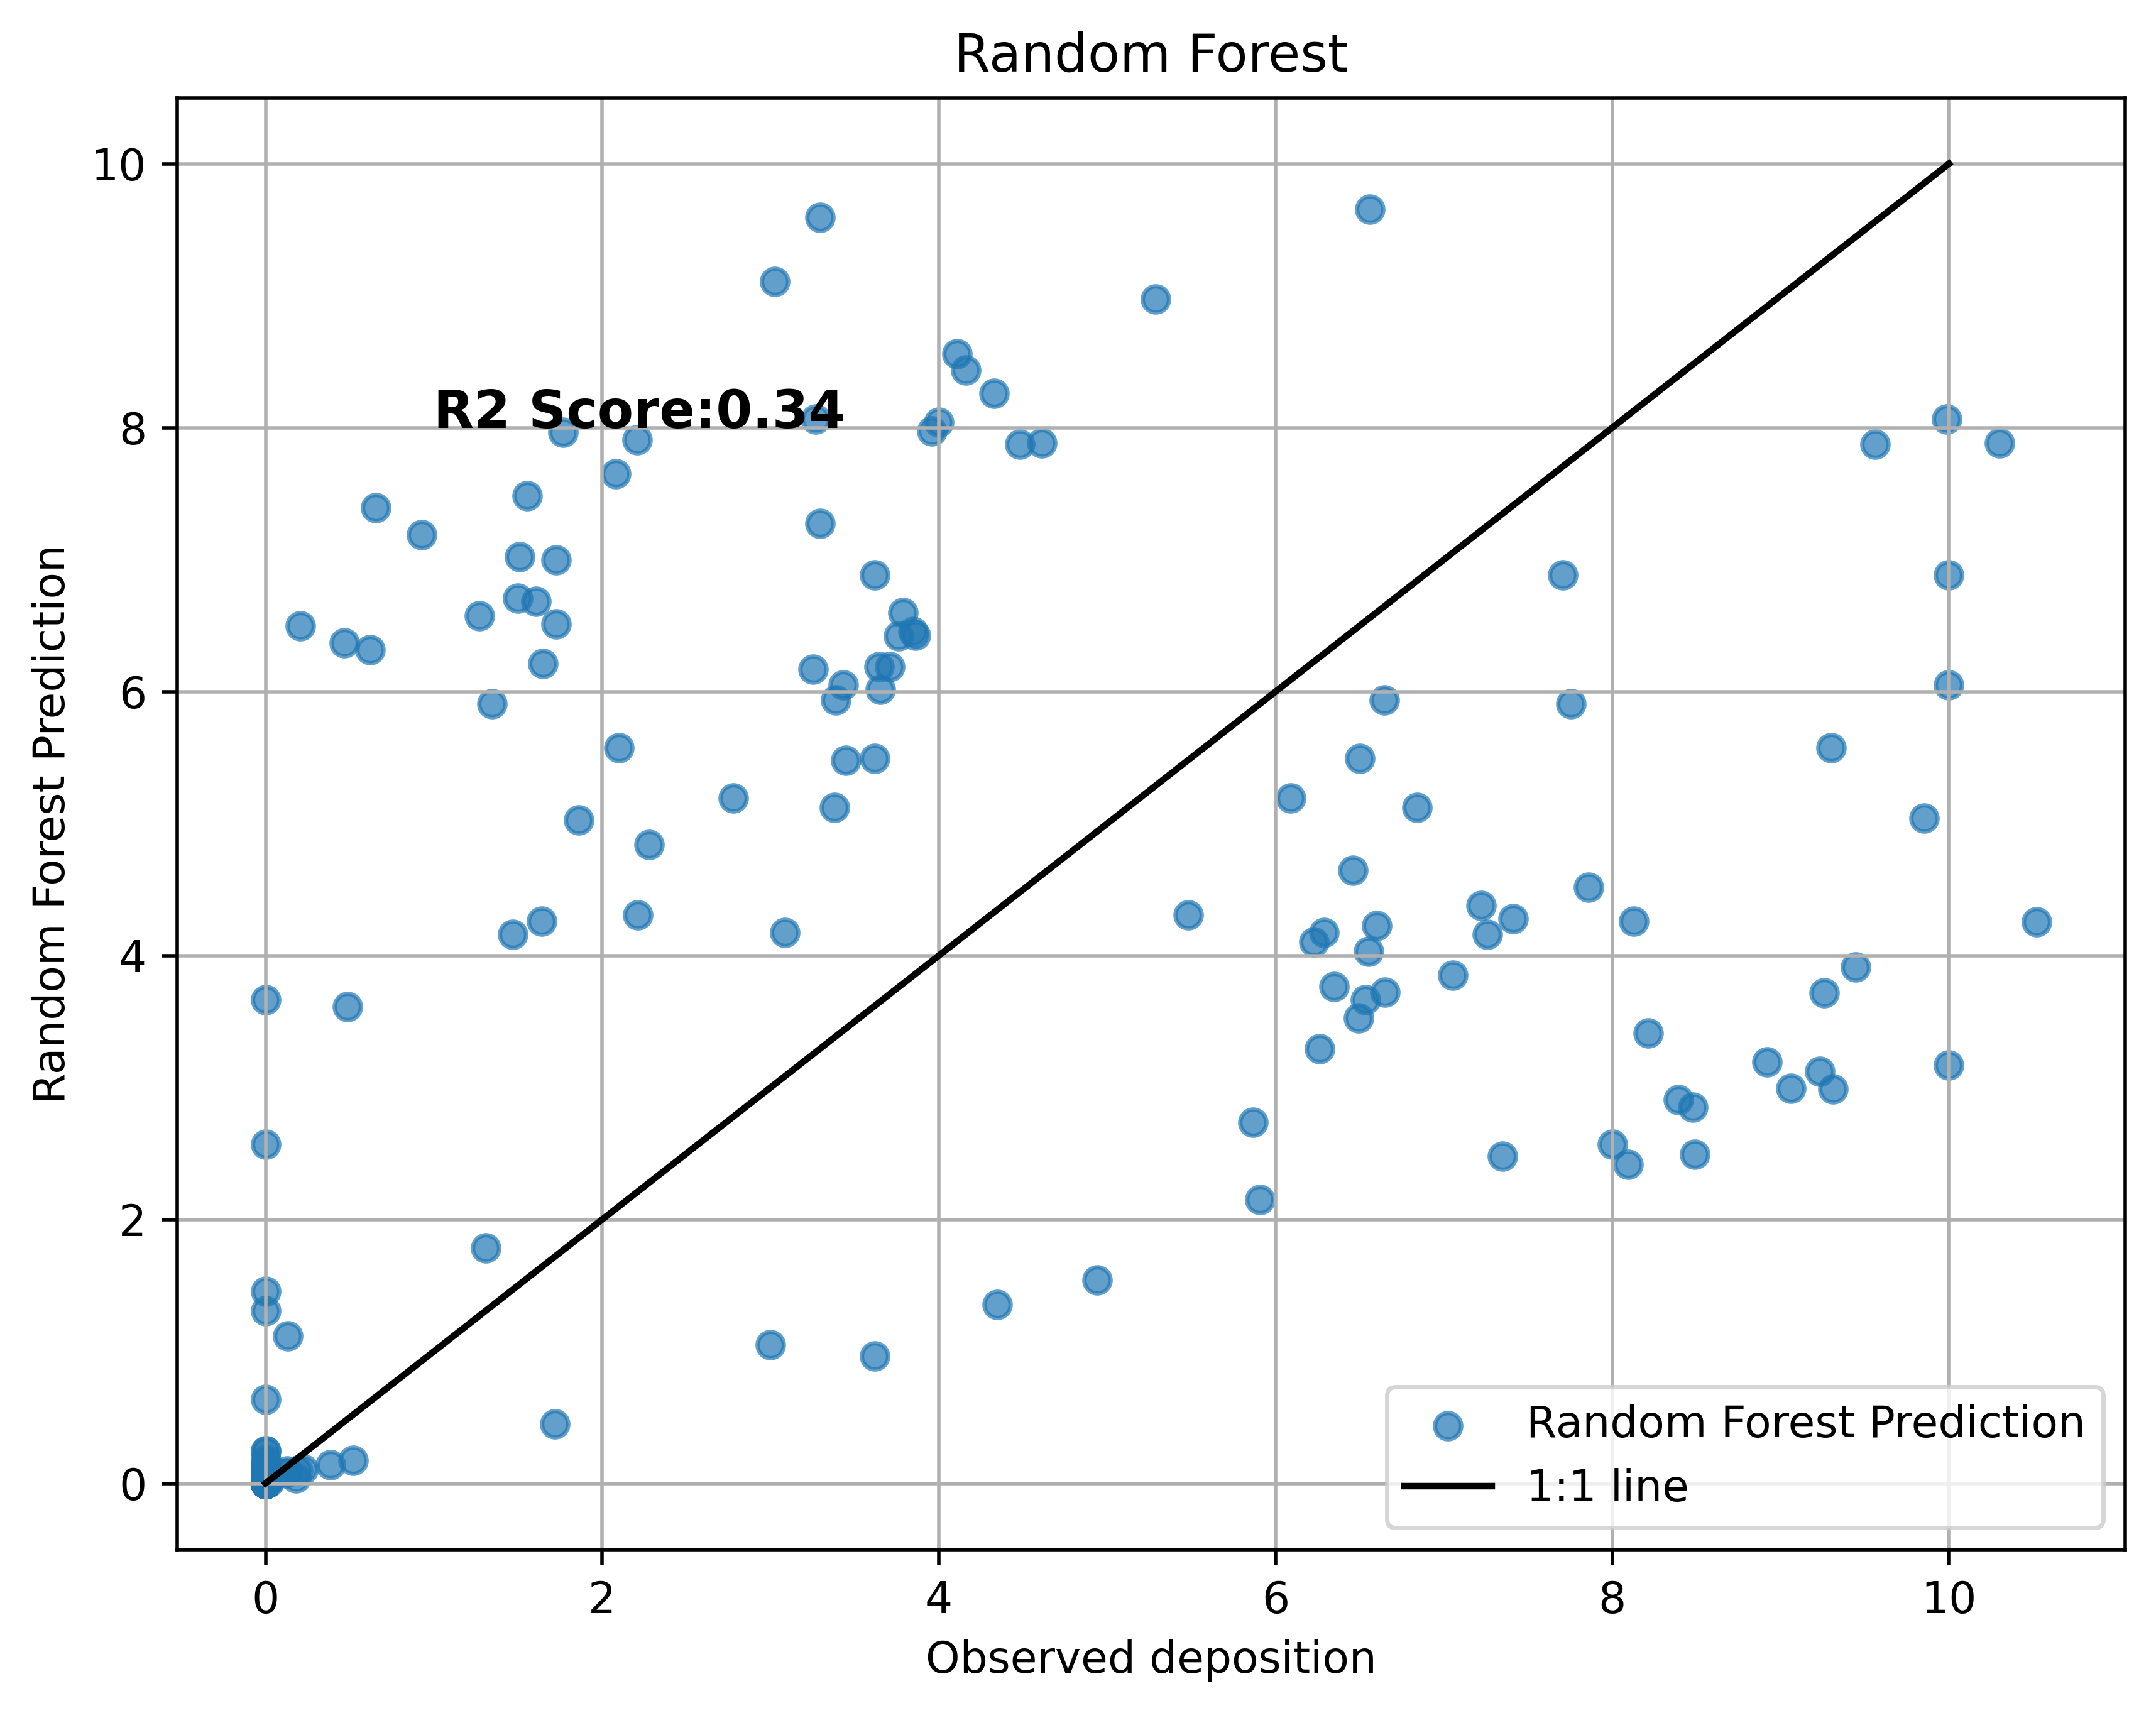

In [21]:

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf_regressor = RandomForestRegressor(random_state=120)

grid_search = GridSearchCV(rf_regressor, param_grid, cv=5, scoring='r2')
grid_search.fit(xtrain, ytrain)

best_rf_regressor = grid_search.best_estimator_

ypred_best = best_rf_regressor.predict(xtest)

mse_best = mean_squared_error(ytest, ypred_best)
mae_best = mean_absolute_error(ytest, ypred_best)
r2_best = r2_score(ytest, ypred_best)

print('RandomForestRegressor with Hyperparameter Tuning:')
print('Best Parameters:', grid_search.best_params_)
print('MSE:', round(mse_best, 4))
print('MAE:', round(mae_best, 4))
print('R2 Score:', round(r2_best, 4))

# Create a scatter plot
plt.figure(figsize=(8, 6), dpi = 500)
plt.scatter(ytest, ypred, alpha=0.7, label=f'{alg} Prediction')
x_coordinates = [0, 10]
y_coordinates = [0, 10]
plt.plot(x_coordinates, y_coordinates, c='black', label='1:1 line')
plt.text(1,8, f'R2 Score:{round(r2_score(ytest,ypred),2)}', fontsize=12, fontweight='bold')
plt.xlabel('Observed deposition')
plt.ylabel(f'{alg} Prediction')
plt.title(f'{alg}')
plt.legend()
plt.grid(True)
plt.show()


In [23]:
CFNPR = pd.read_excel("Case6_DPM_right_only.xlsx")
CFNPR

,10,20,30,40,50,60,70,80,90,100,Flow Rate[L/min],Velocity,Half Cone angle,region,name
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Vestibule,0
1,2.200000,8.000000,9.200000,8.400000,8.120000,9.200000,8.300000,9.300000,8.400000,9.210000,8.7,19.2,16.0,Nasal Valve,1
2,0.480000,1.910000,1.760000,1.560000,1.880000,1.760000,1.640000,1.660000,1.510000,1.780000,8.7,19.2,16.0,Anterior Turbinate,2
3,0.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Nasopharynx,3
4,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Outlet,4
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,39.5,Vestibule,0
6,1.820000,6.046667,7.060000,6.600000,6.160000,7.053333,6.760000,7.340000,6.853333,7.060000,8.7,19.2,39.5,Nasal Valve,1
7,0.333333,3.013333,3.753333,3.253333,3.673333,3.786667,3.133333,3.573333,3.053333,3.760000,8.7,19.2,39.5,Anterior Turbinate,2
8,0.240000,0.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,39.5,Nasopharynx,3
9,3.140000,0.120000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,39.5,Outlet,4


In [25]:
CFNPR_melt=pd.melt(CFNPR,id_vars=['Flow Rate[L/min]','region', 'name', 'Velocity','Half Cone angle'],
           value_vars=[10,20,30,40,50,60,70,80,90,100],
           value_name='Dose')

C:\Users\DFMRendering\AppData\Local\Temp\ipykernel_15744\2445763922.py:6: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.swarmplot(x="region", y="Dose", data=CFNPR_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 75.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 76.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 85.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


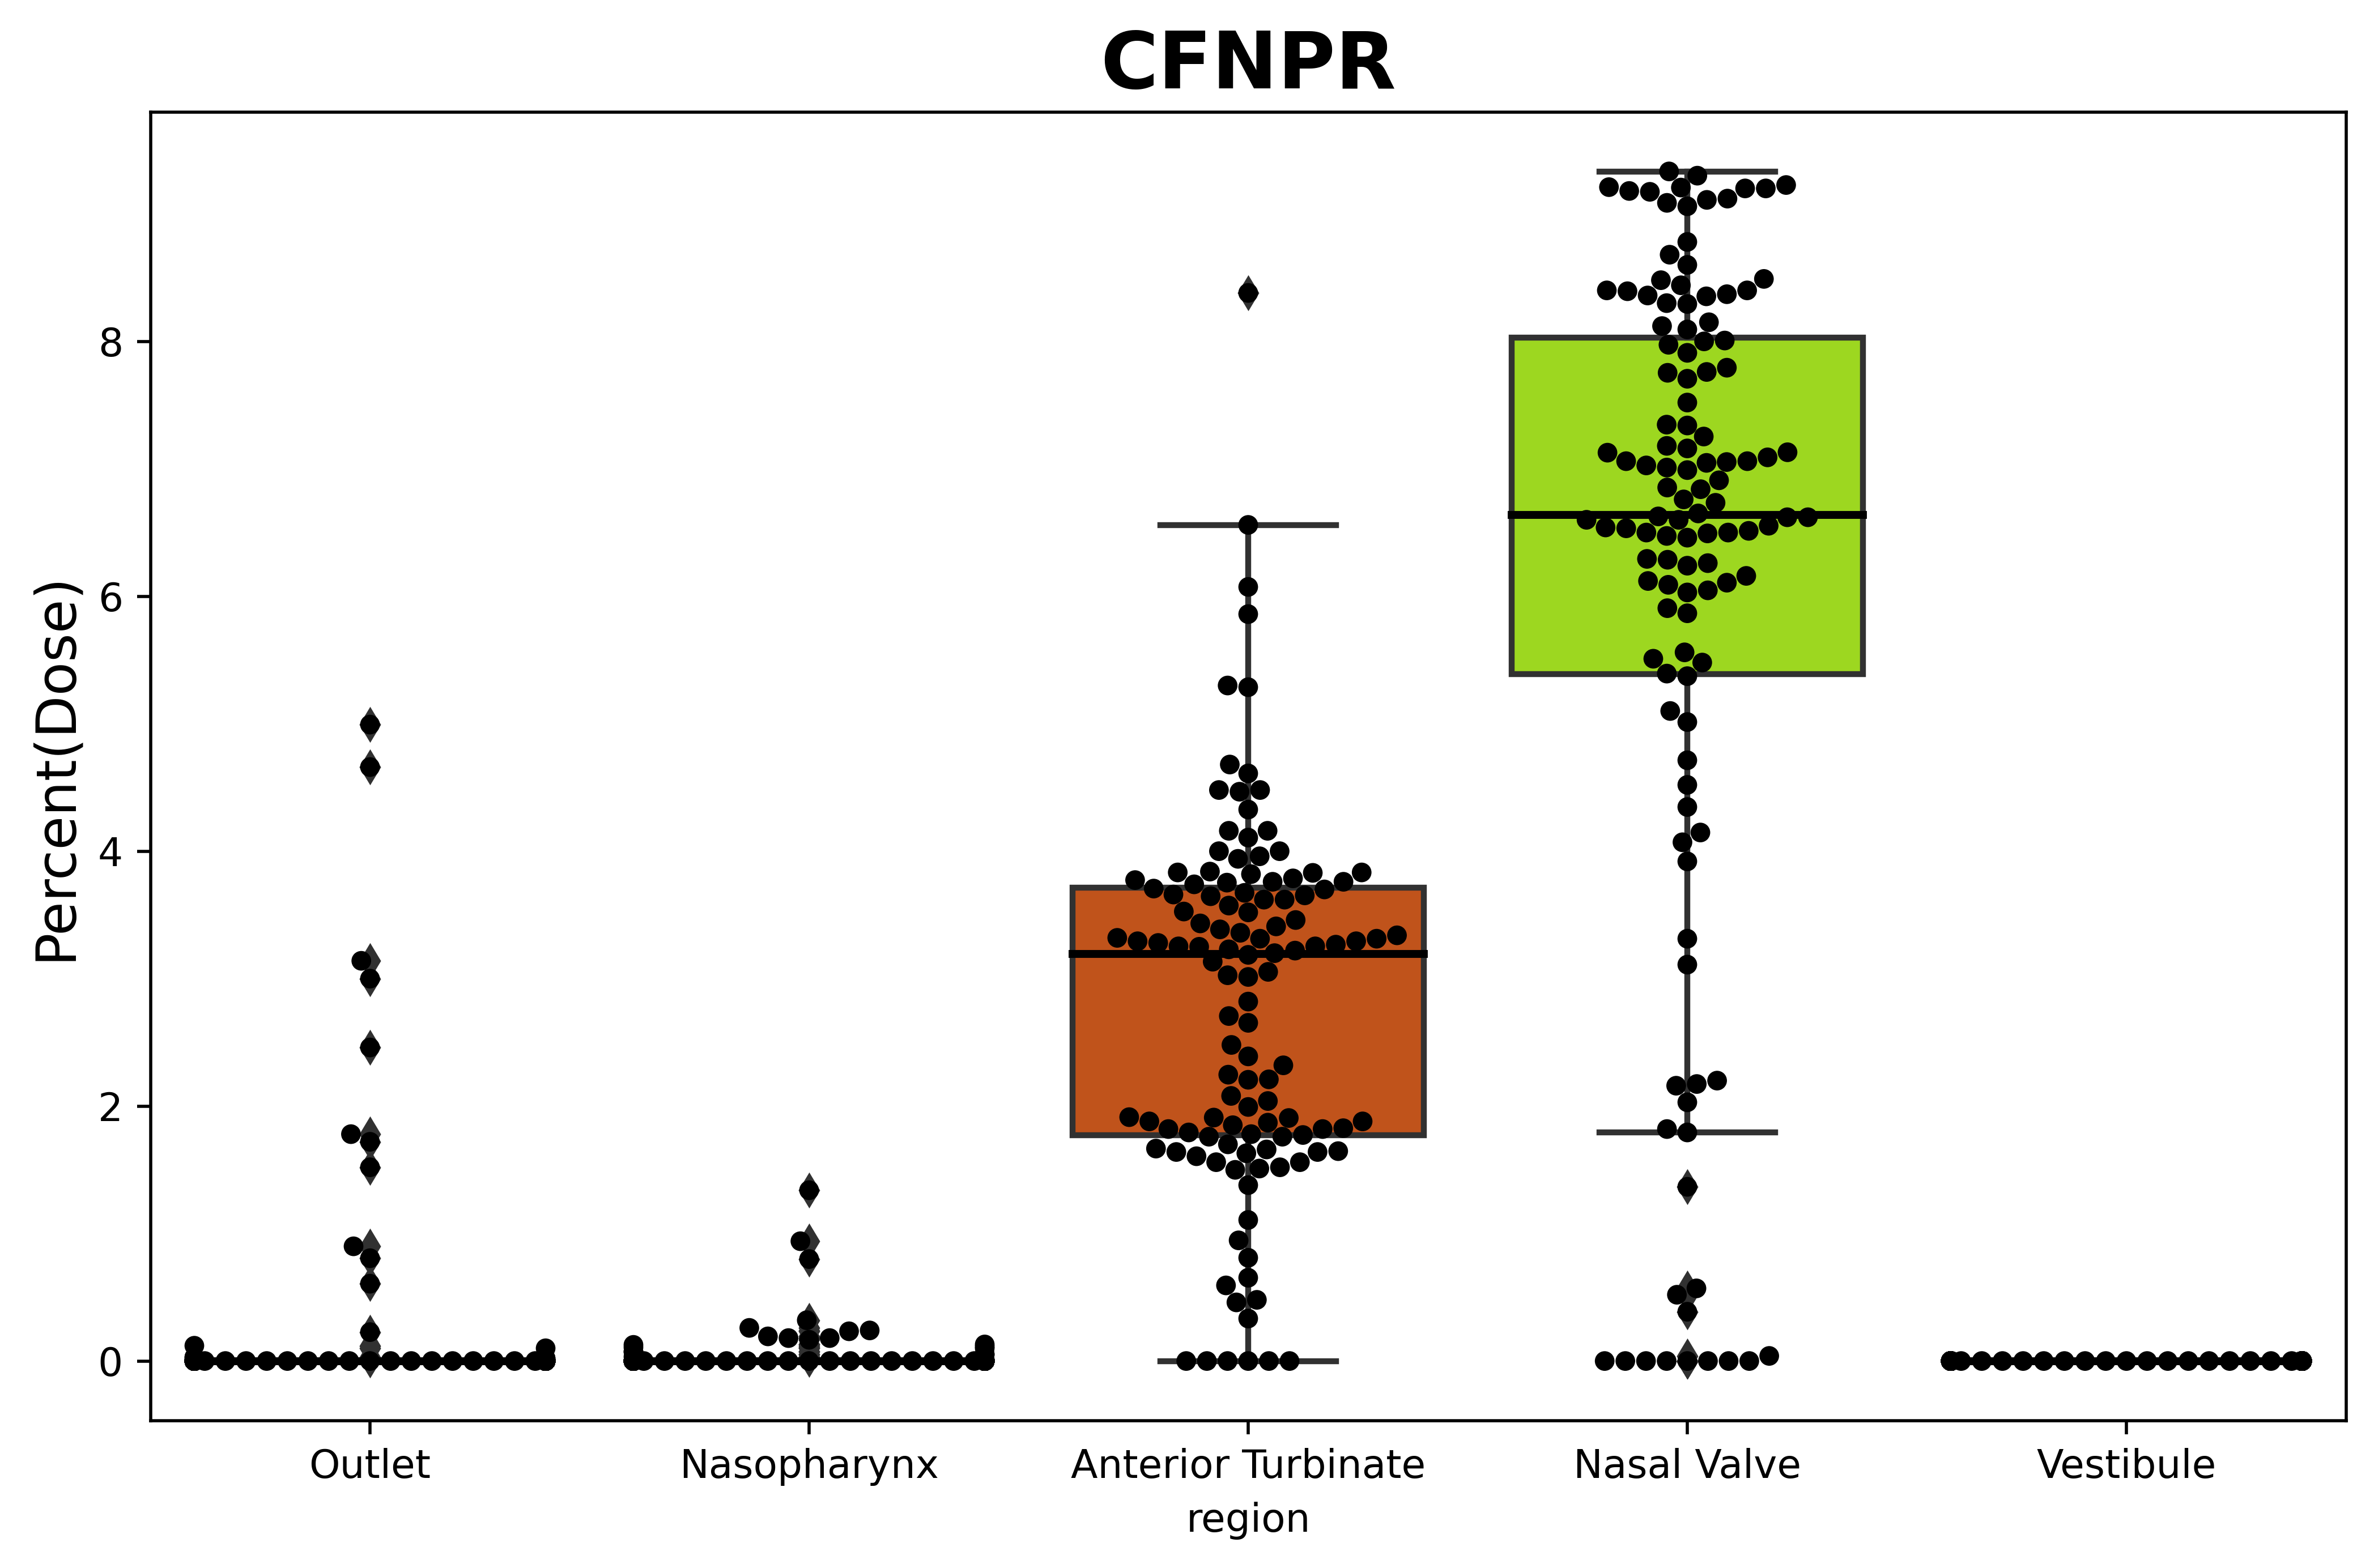

In [27]:
my_pal = {"Vestibule": "#24247e", "Nasal Valve": "#9dd720", "Anterior Turbinate":"#c0531b", "Nasopharynx":"#b61b1c","Outlet":"#DC143C"}
my_pal_2 = {"Vestibule": "black", "Nasal Valve": "black", "Anterior Turbinate":"black", "Nasopharynx":"black", "Outlet":"black"}
medianprops = dict(linestyle='-', linewidth=2, color='black')
plt.figure(figsize=(10,6), dpi = 500)
ax = sns.boxplot(x="region", y="Dose", data=CFNPR_melt, palette=my_pal, saturation=100, medianprops=medianprops, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
ax = sns.swarmplot(x="region", y="Dose", data=CFNPR_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
plt.ylabel('Percent(Dose)', fontsize= 14)
plt.title('CFNPR',fontsize=20, fontweight = 'bold')
plt.show()

In [28]:
CFNPL = pd.read_excel("Case6_DPM_left_only.xlsx")
CFNPL

,10,20,30,40,50,60,70,80,90,100,Flow Rate[L/min],Velocity,Half Cone angle,region,name
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Vestibule,0
1,0.906667,1.660000,1.960000,1.706667,1.726667,1.826667,2.106667,2.100000,1.966667,2.006667,8.7,19.2,16.0,Nasal Valve,1
2,4.153333,8.340000,9.040000,8.293333,8.273333,9.173333,7.893333,8.900000,8.033333,8.993333,8.7,19.2,16.0,Anterior Turbinate,2
3,0.146667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Nasopharynx,3
4,0.266667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Outlet,4
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,39.5,Vestibule,0
6,1.093333,3.233333,3.833333,3.386667,3.226667,3.866667,3.653333,3.946667,3.793333,3.740000,8.7,19.2,39.5,Nasal Valve,1
7,3.620000,6.766667,7.166667,6.613333,6.773333,7.133333,6.346667,7.053333,6.206667,7.260000,8.7,19.2,39.5,Anterior Turbinate,2
8,0.140000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,39.5,Nasopharynx,3
9,0.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,39.5,Outlet,4


In [29]:
CFNPL_melt=pd.melt(CFNPL,id_vars=['Flow Rate[L/min]','region', 'name', 'Velocity','Half Cone angle'],
           value_vars=[10,20,30,40,50,60,70,80,90,100],
           value_name='Dose')

C:\Users\DFMRendering\AppData\Local\Temp\ipykernel_15744\2741548333.py:6: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.swarmplot(x="region", y="Dose", data=CFNPL_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 82.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 85.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 85.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


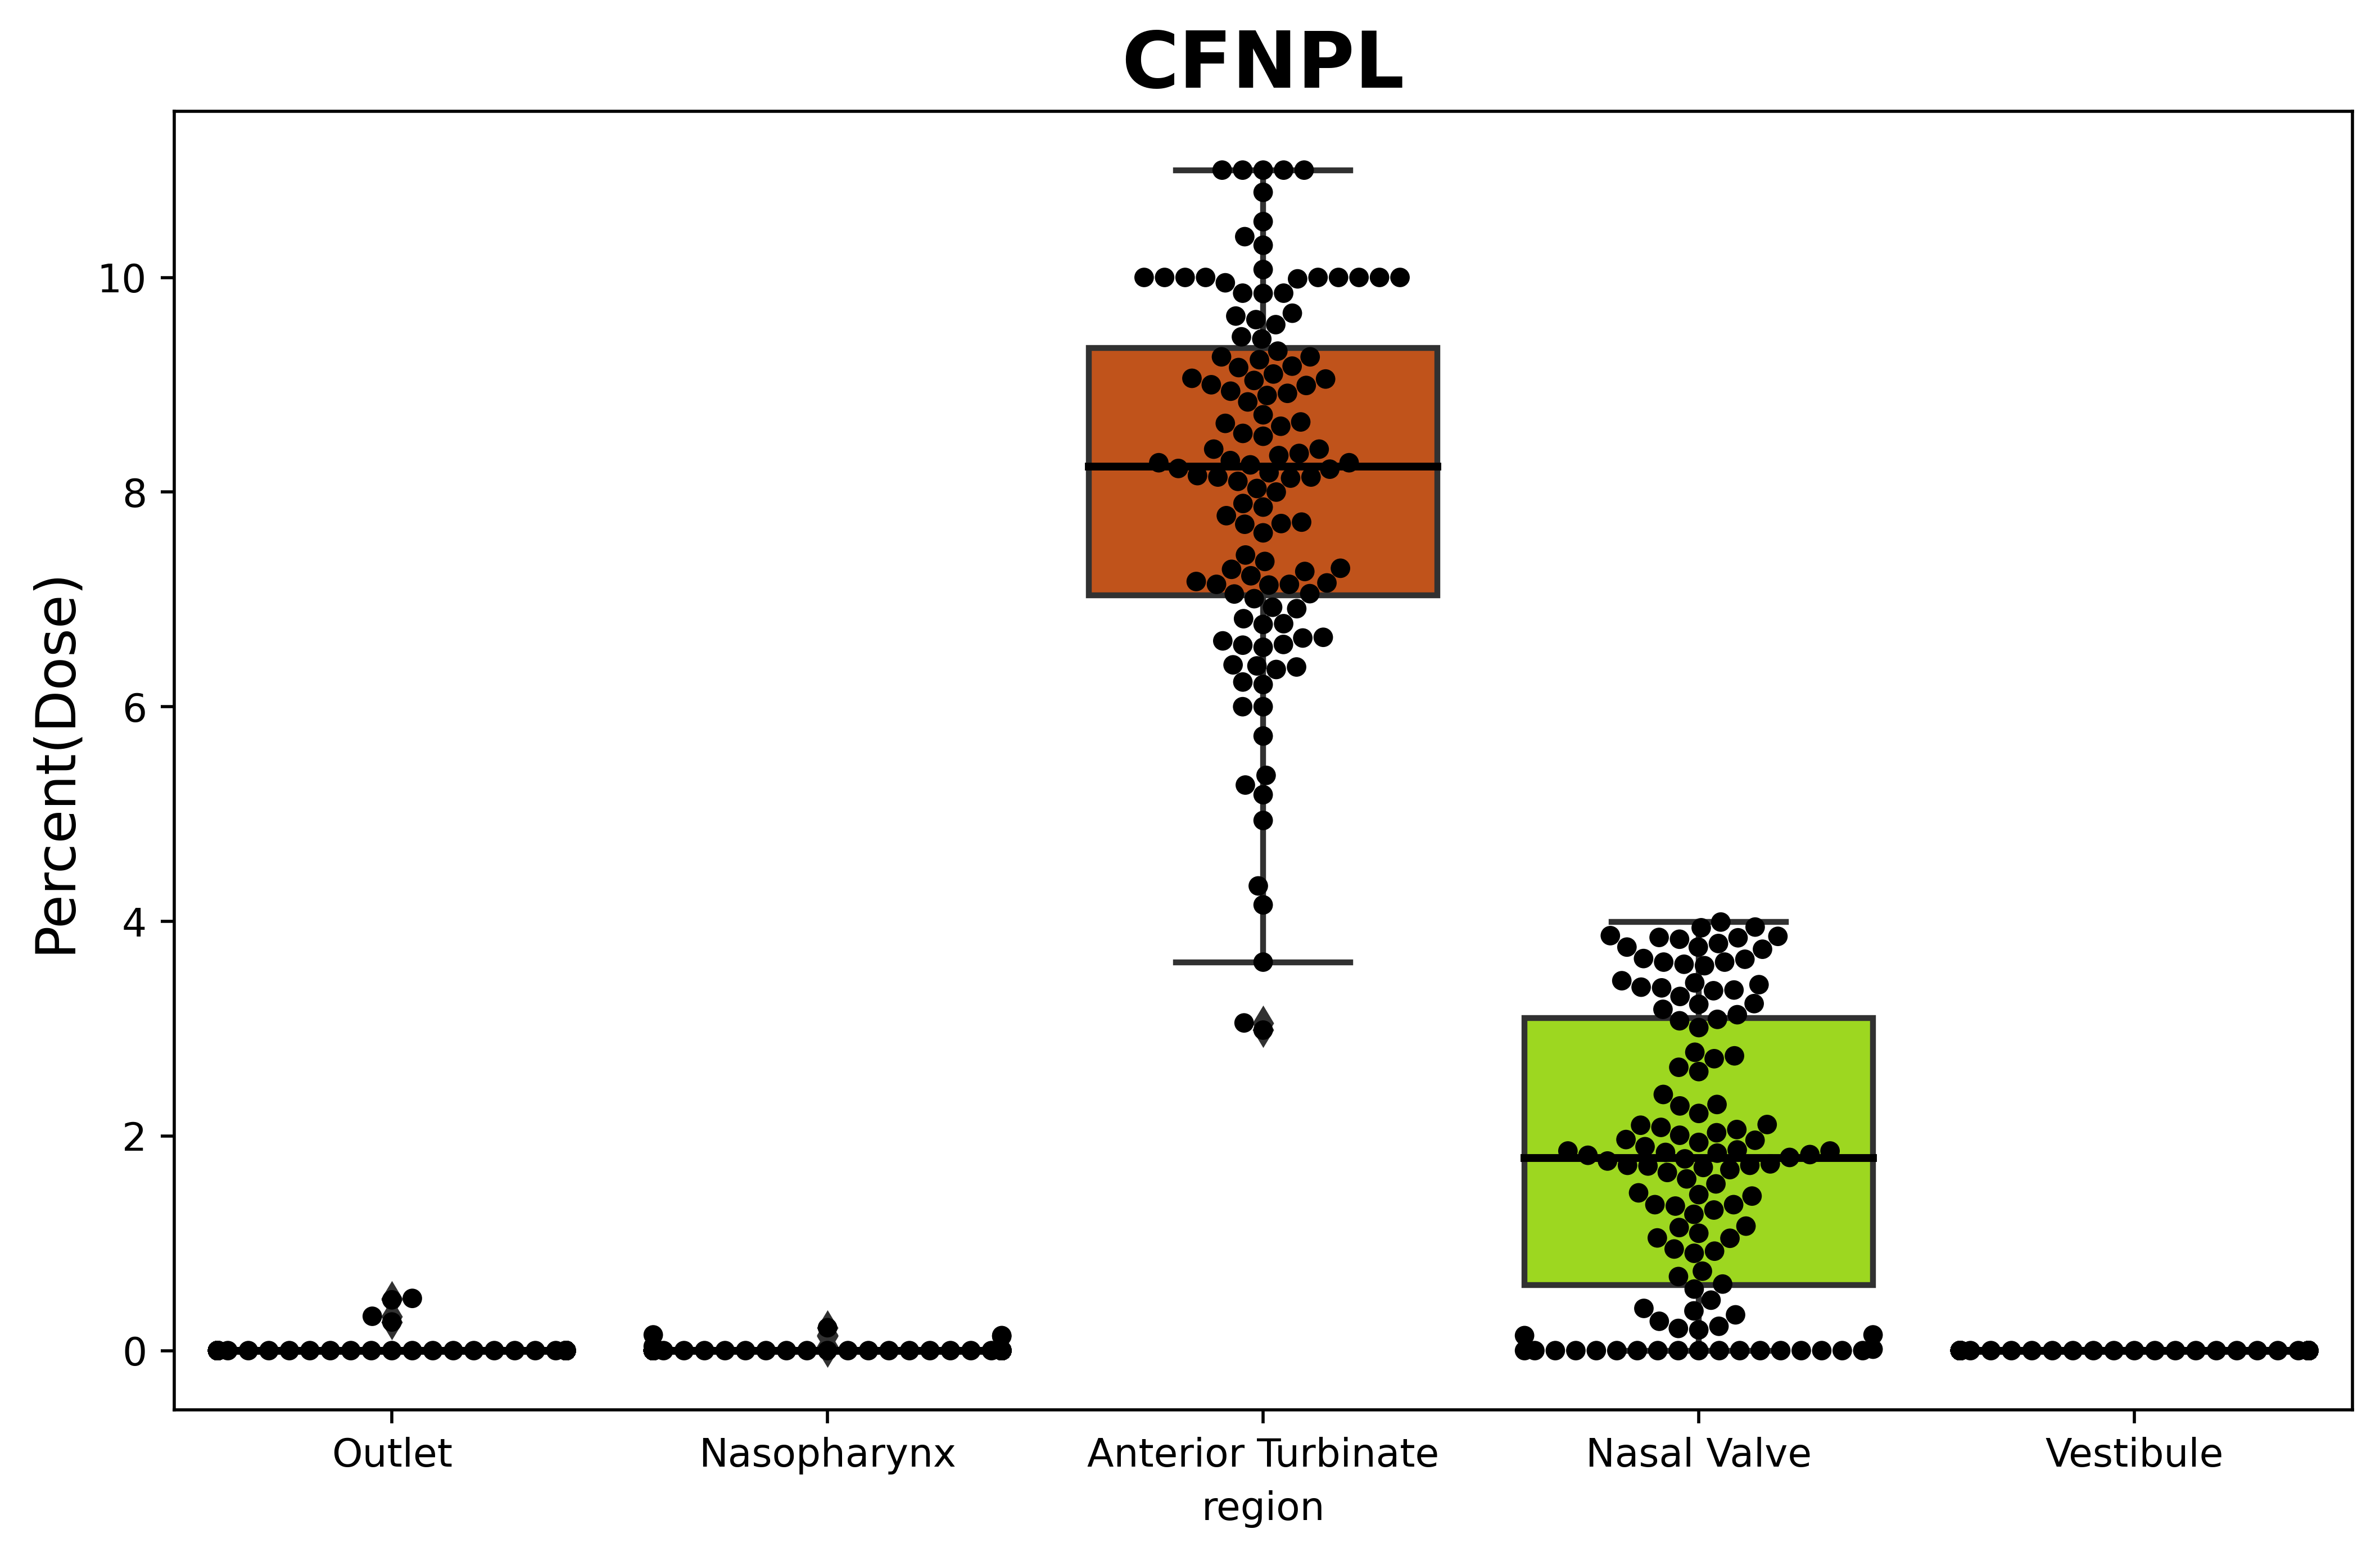

In [30]:
my_pal = {"Vestibule": "#24247e", "Nasal Valve": "#9dd720", "Anterior Turbinate":"#c0531b", "Nasopharynx":"#b61b1c","Outlet":"#DC143C"}
my_pal_2 = {"Vestibule": "black", "Nasal Valve": "black", "Anterior Turbinate":"black", "Nasopharynx":"black", "Outlet":"black"}
medianprops = dict(linestyle='-', linewidth=2, color='black')
plt.figure(figsize=(10,6), dpi = 500)
ax = sns.boxplot(x="region", y="Dose", data=CFNPL_melt, palette=my_pal, saturation=100, medianprops=medianprops, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
ax = sns.swarmplot(x="region", y="Dose", data=CFNPL_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
plt.ylabel('Percent(Dose)', fontsize= 14)
plt.title('CFNPL',fontsize=20, fontweight = 'bold')
plt.show()

## Case: 37 years old_ healthy

In [34]:
df_37Y = pd.read_excel("Case37Y_DPM.xlsx")
df_37Y

,10,20,30,40,50,60,70,80,90,100,Flow Rate[L/min],Velocity,Half Cone angle,region,name
0,0.000000,0.133340,0.233345,0.206677,0.280014,0.300015,0.340017,0.353351,0.380019,0.313349,8.7,19.2,16.0,Vestibule,0
1,0.000000,3.560178,5.733620,5.220261,5.213594,5.733620,4.973582,5.240262,4.946914,5.700285,8.7,19.2,16.0,Nasal Valve,1
2,0.760038,3.486841,5.013584,4.573562,4.506892,4.966915,4.686901,5.406937,4.673567,4.986916,8.7,19.2,16.0,Anterior Turbinate,2
3,0.000000,0.080004,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Nasopharynx,3
4,5.206927,2.333450,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.7,19.2,16.0,Outlet,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.000000,0.000000,0.180009,1.393403,2.020101,2.860143,2.820141,3.506842,3.486841,3.866860,15.0,2.0,39.5,Vestibule,0
116,0.000000,0.393353,3.906862,4.326883,4.726903,4.706902,4.206877,4.240212,3.826858,4.146874,15.0,2.0,39.5,Nasal Valve,1
117,5.126923,9.500475,6.913679,4.280214,3.253496,3.433505,2.973482,3.246829,2.673467,2.940147,15.0,2.0,39.5,Anterior Turbinate,2
118,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.0,2.0,39.5,Nasopharynx,3


In [35]:
df_37Y_melt=pd.melt(df_37Y,id_vars=['Flow Rate[L/min]','region', 'name', 'Velocity','Half Cone angle'],
           value_vars=[10,20,30,40,50,60,70,80,90,100],
           value_name='Dose')
df_37Y_melt.describe()

,Flow Rate[L/min],name,Velocity,Half Cone angle,Dose
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,17.900000,2.000000,10.600000,27.750000,1.985144
std,8.937929,1.414803,8.603586,11.754899,2.328828
min,8.700000,0.000000,2.000000,16.000000,0.000000
25%,8.700000,1.000000,2.000000,16.000000,0.000000
50%,15.000000,2.000000,10.600000,27.750000,0.583363
75%,30.000000,3.000000,19.200000,39.500000,3.715186
max,30.000000,4.000000,19.200000,39.500000,11.000550


C:\Users\DFMRendering\AppData\Local\Temp\ipykernel_15744\6467292.py:7: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.swarmplot(x="region", y="Dose", data=df_37Y_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 78.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 91.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\li

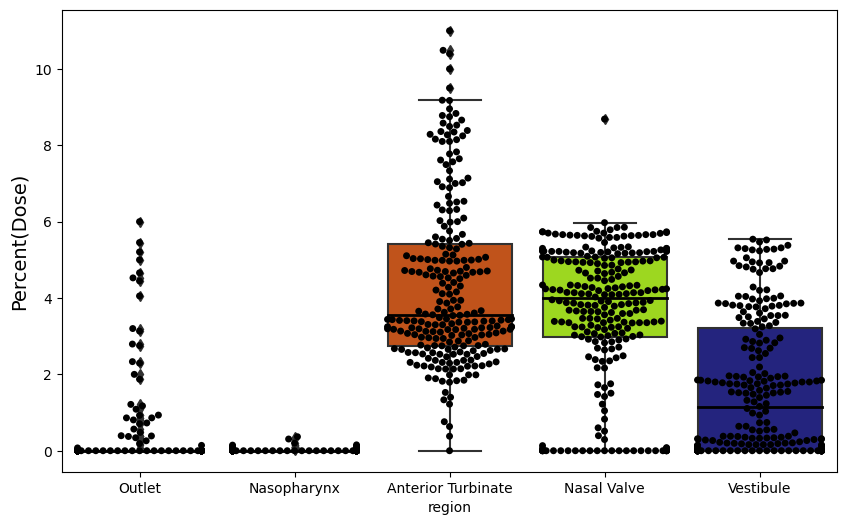

In [37]:
my_pal = {"Vestibule": "#24247e", "Nasal Valve": "#9dd720", "Anterior Turbinate":"#c0531b", "Nasopharynx":"#b61b1c","Outlet":"#DC143C"}
my_pal_2 = {"Vestibule": "black", "Nasal Valve": "black", "Anterior Turbinate":"black", "Nasopharynx":"black", "Outlet":"black"}
medianprops = dict(linestyle='-', linewidth=2, color='black')
plt.figure(figsize=(10,6), dpi = 100)

ax = sns.boxplot(x="region", y="Dose", data=df_37Y_melt, palette=my_pal, saturation=100, medianprops=medianprops, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
ax = sns.swarmplot(x="region", y="Dose", data=df_37Y_melt, palette=my_pal_2, order=['Outlet','Nasopharynx','Anterior Turbinate','Nasal Valve','Vestibule'])
plt.ylabel('Percent(Dose)', fontsize= 14)
plt.show()

Gradient Boosting :
MSE: 0.8698
MAE: 0.623
Score: 0.8385


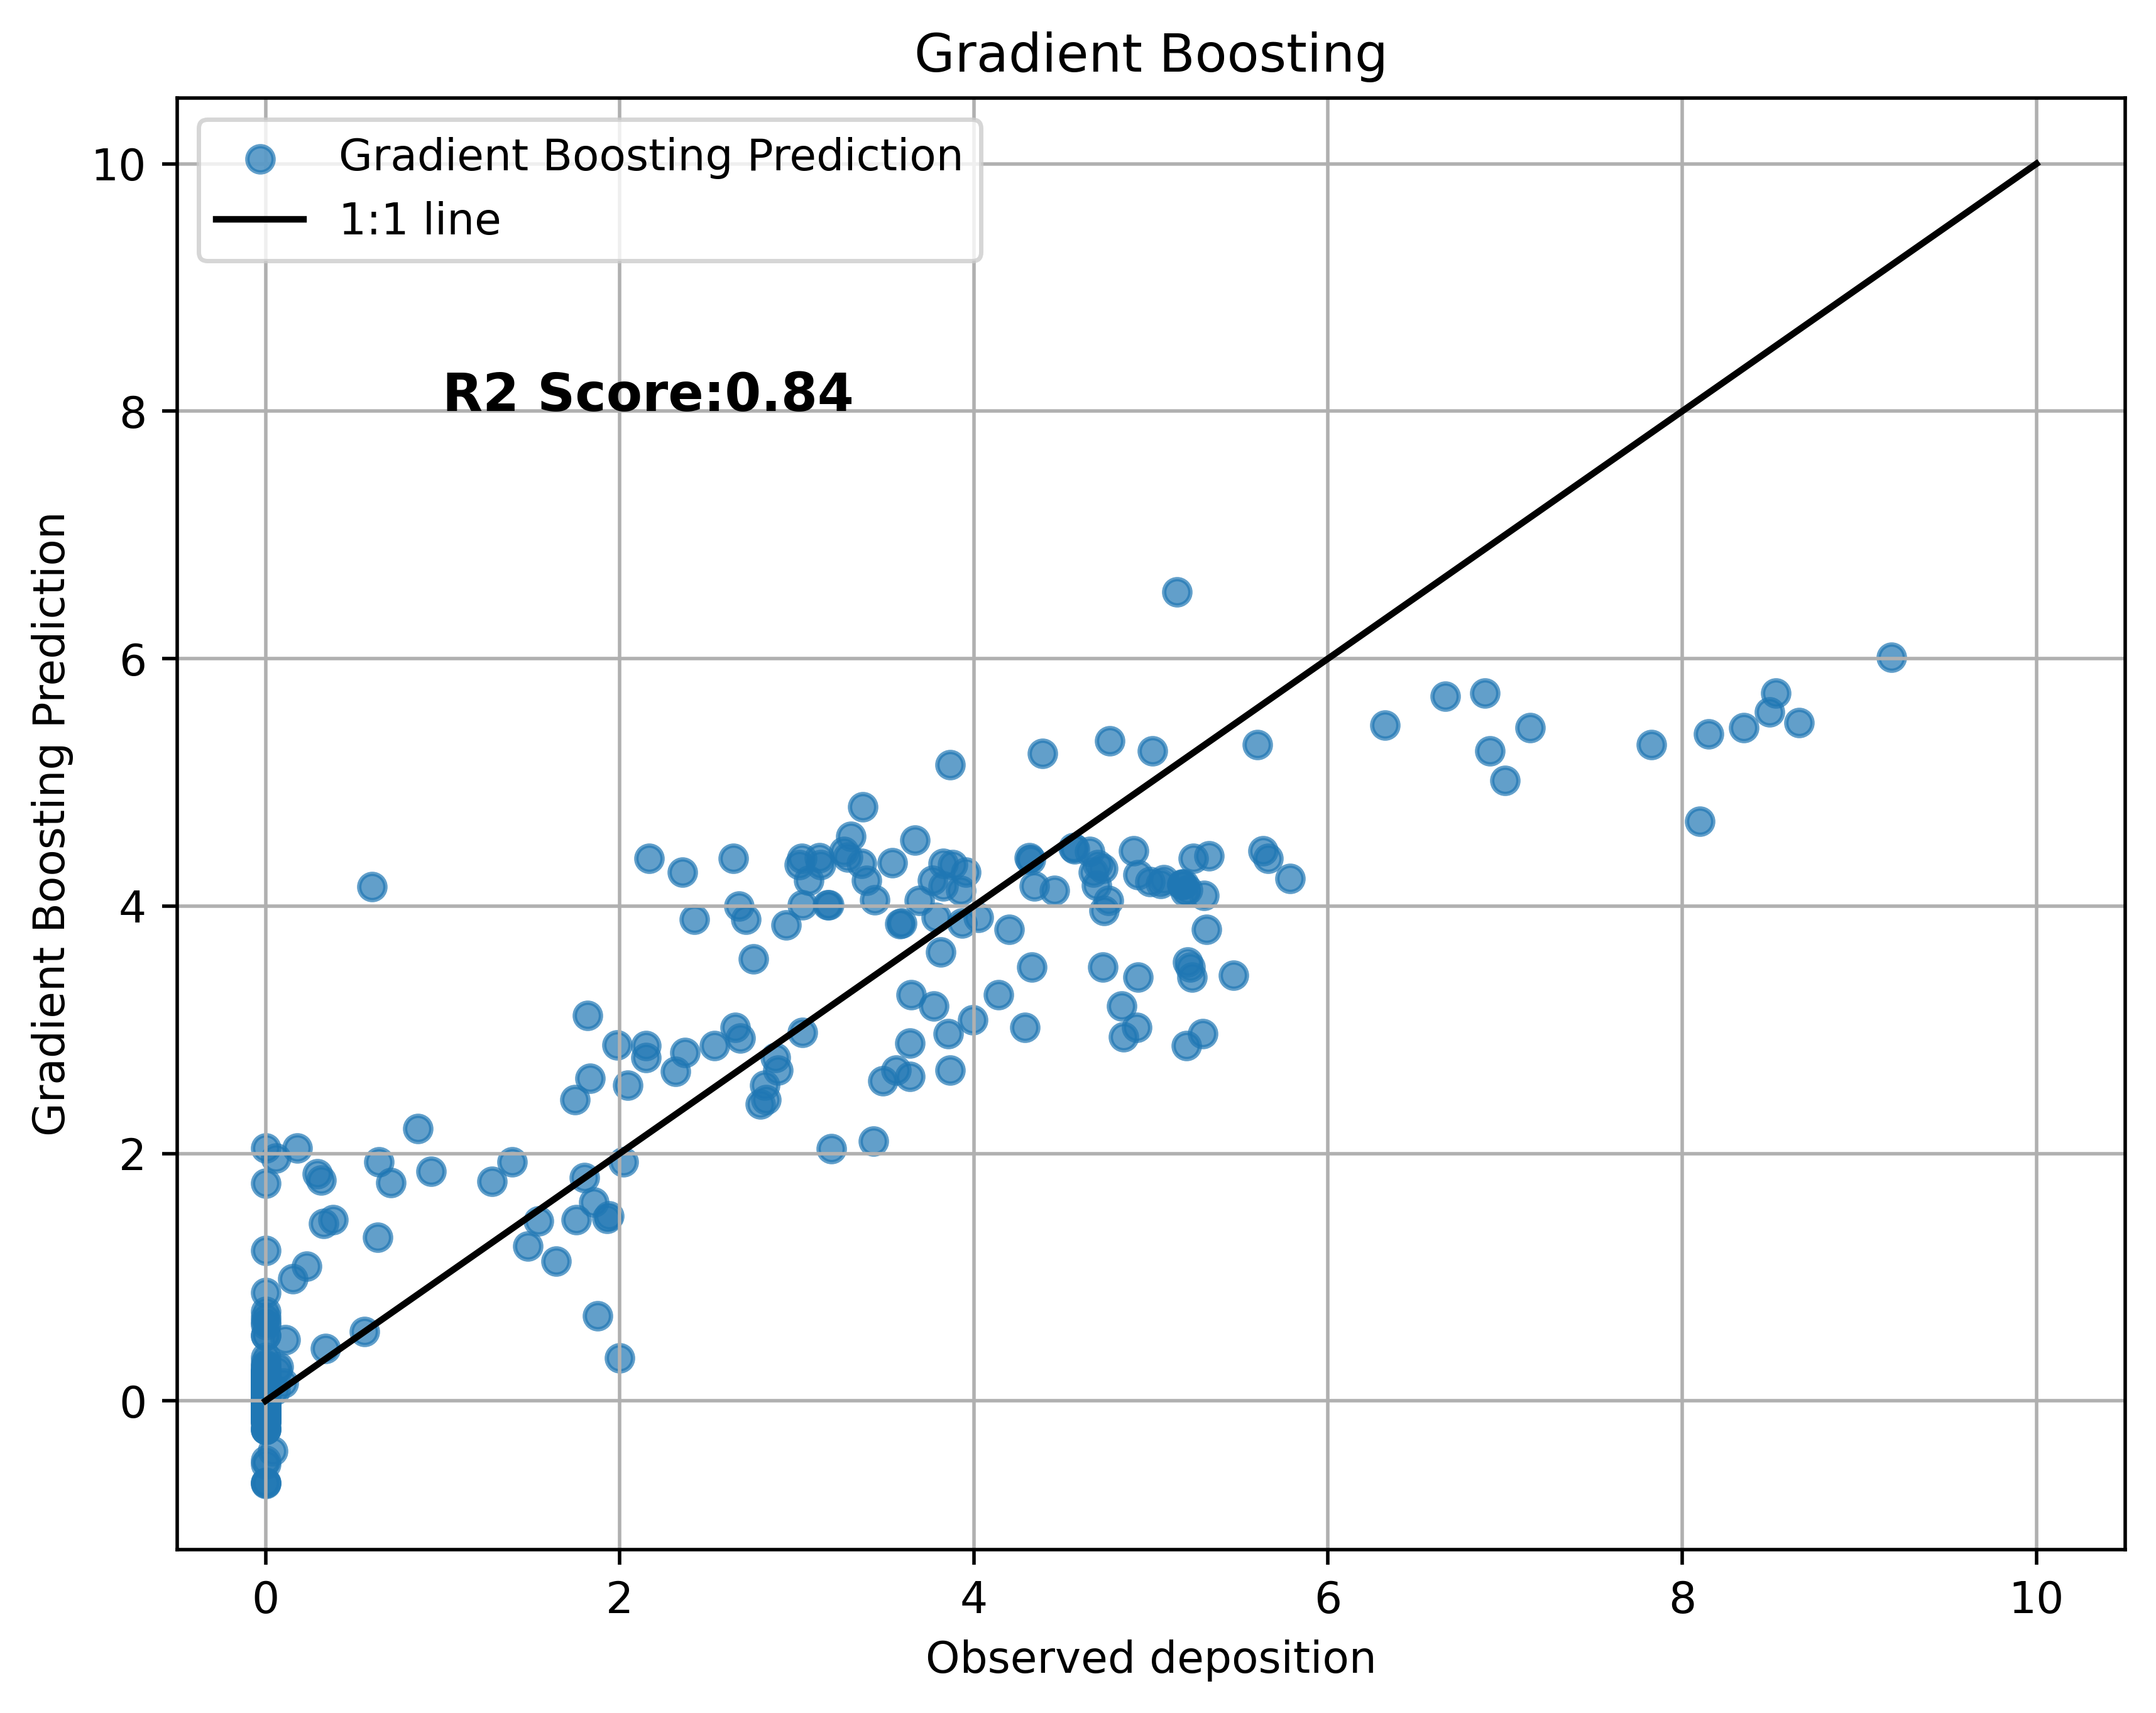

HistGradientBoosting_Regression :
MSE: 0.5362
MAE: 0.455
Score: 0.9004


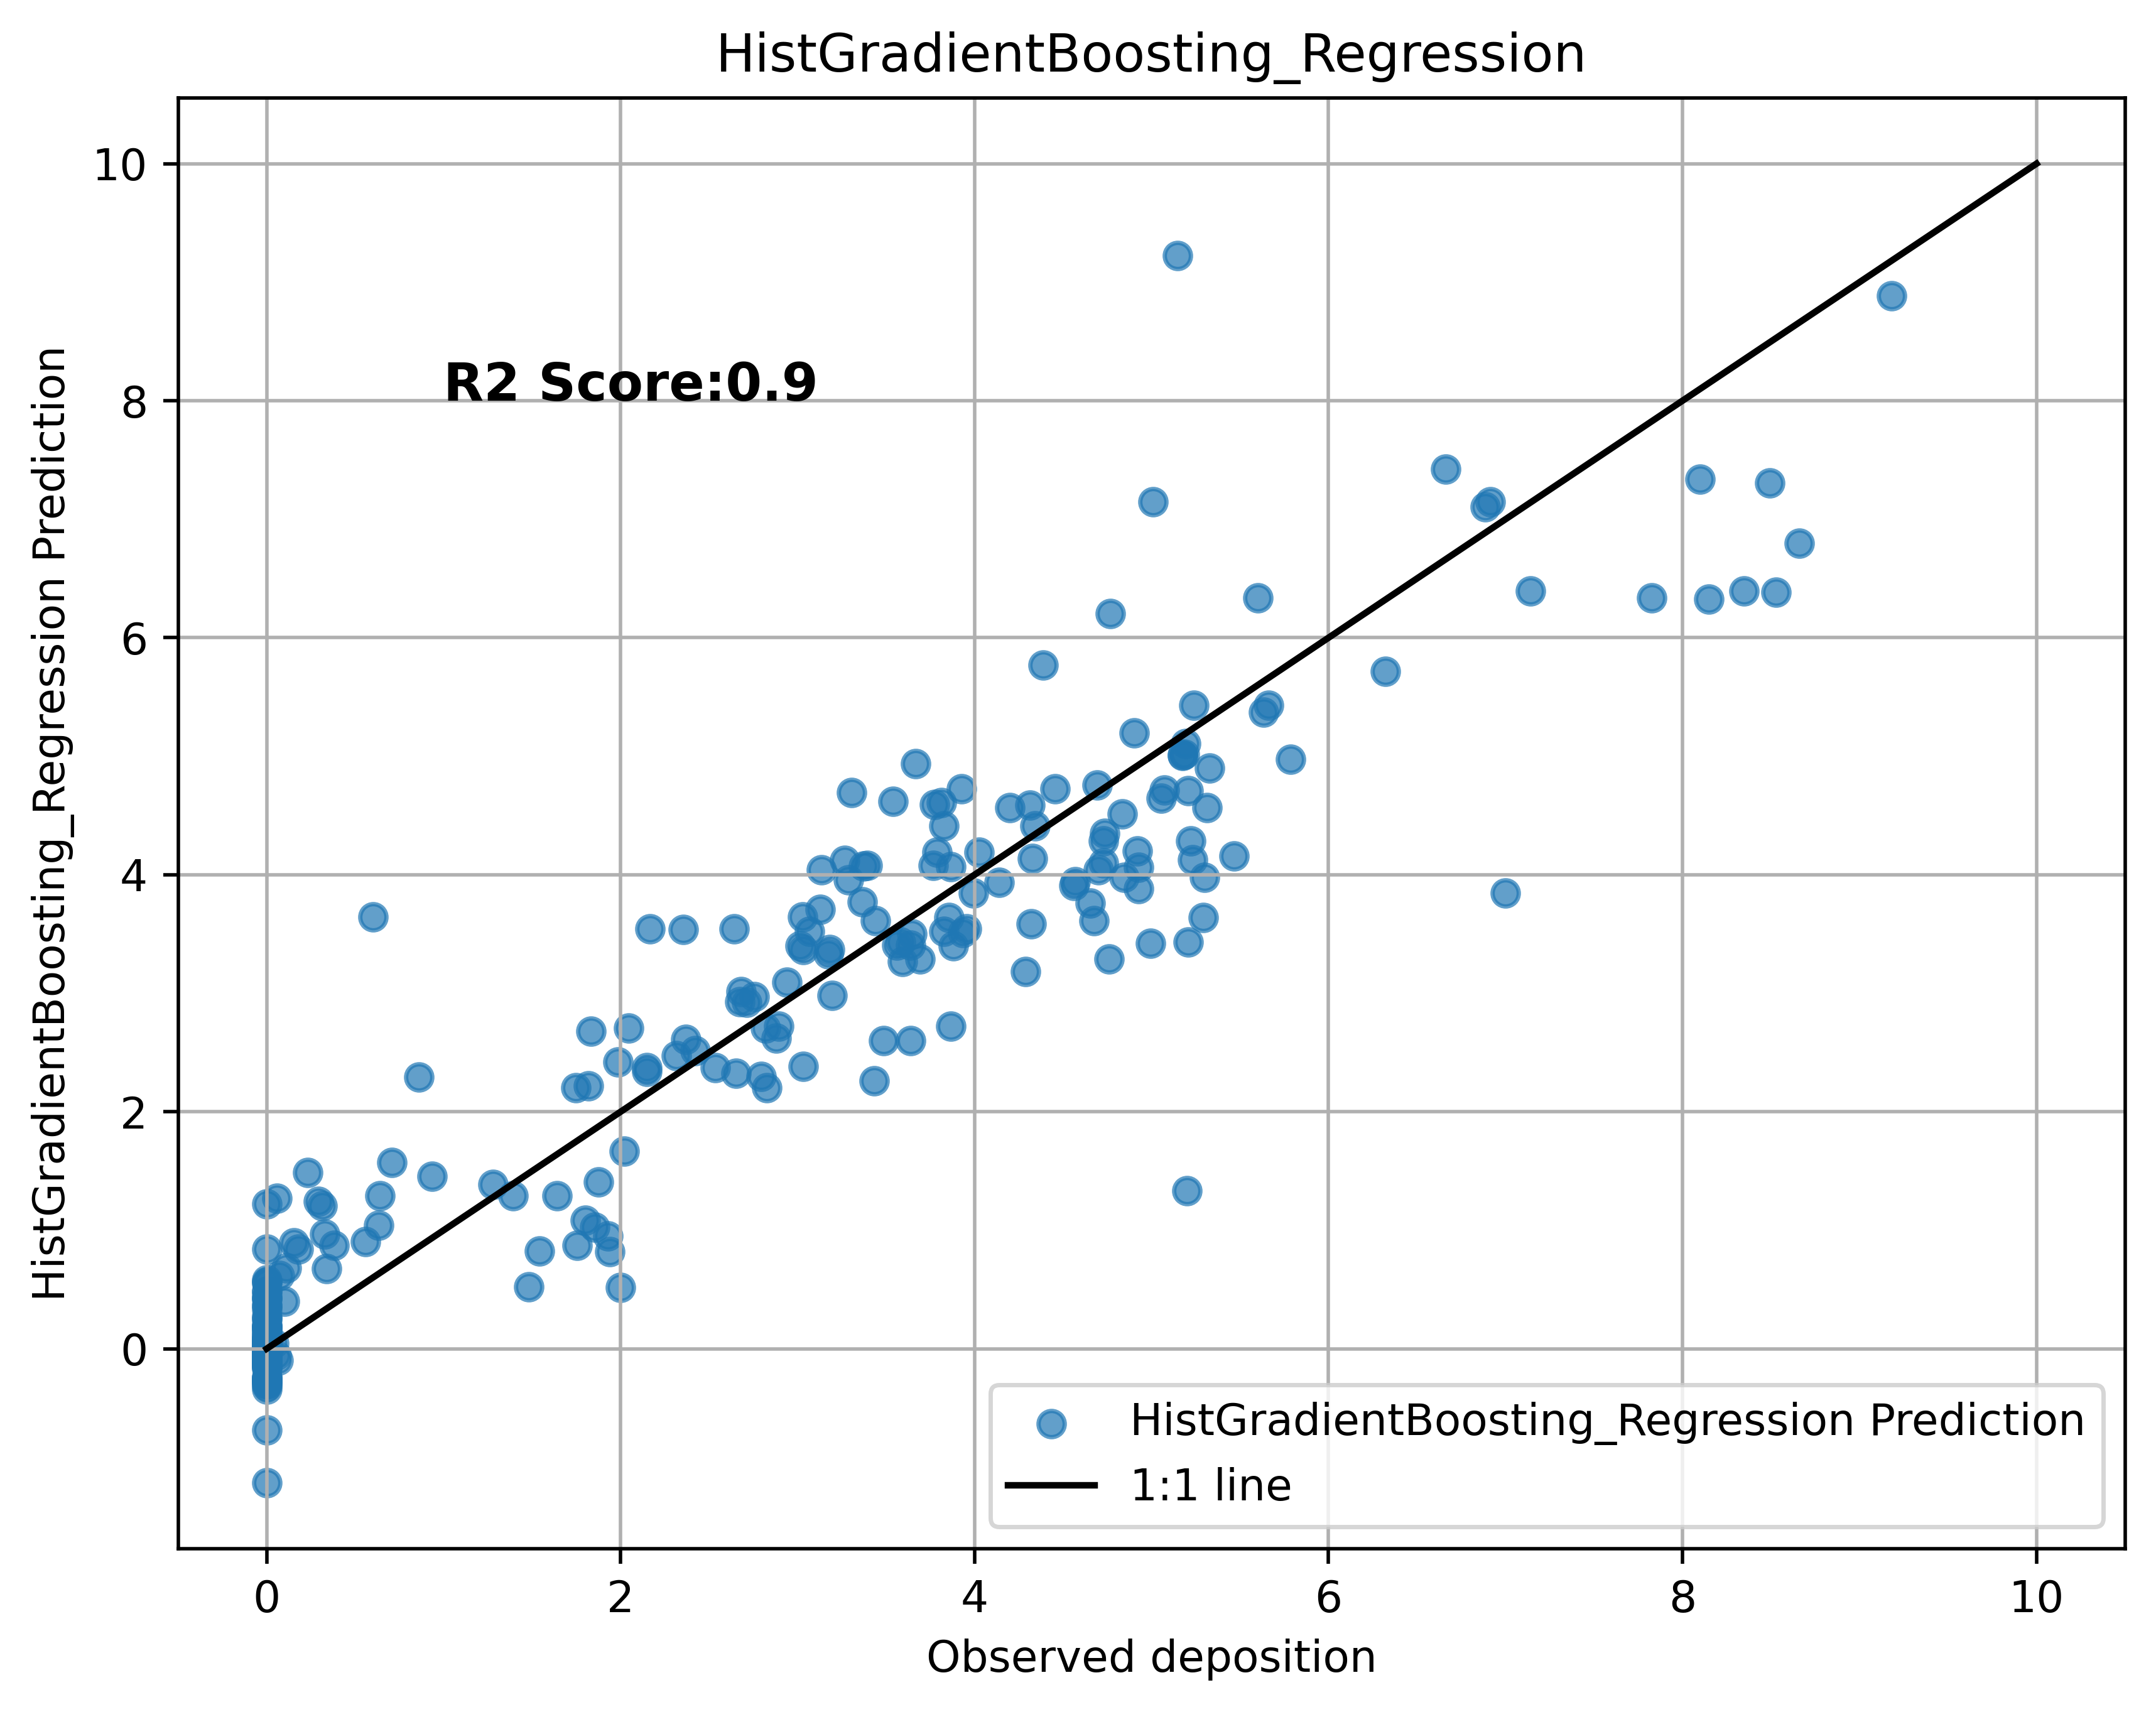

Random Forest :
MSE: 0.6573
MAE: 0.4405
Score: 0.8779


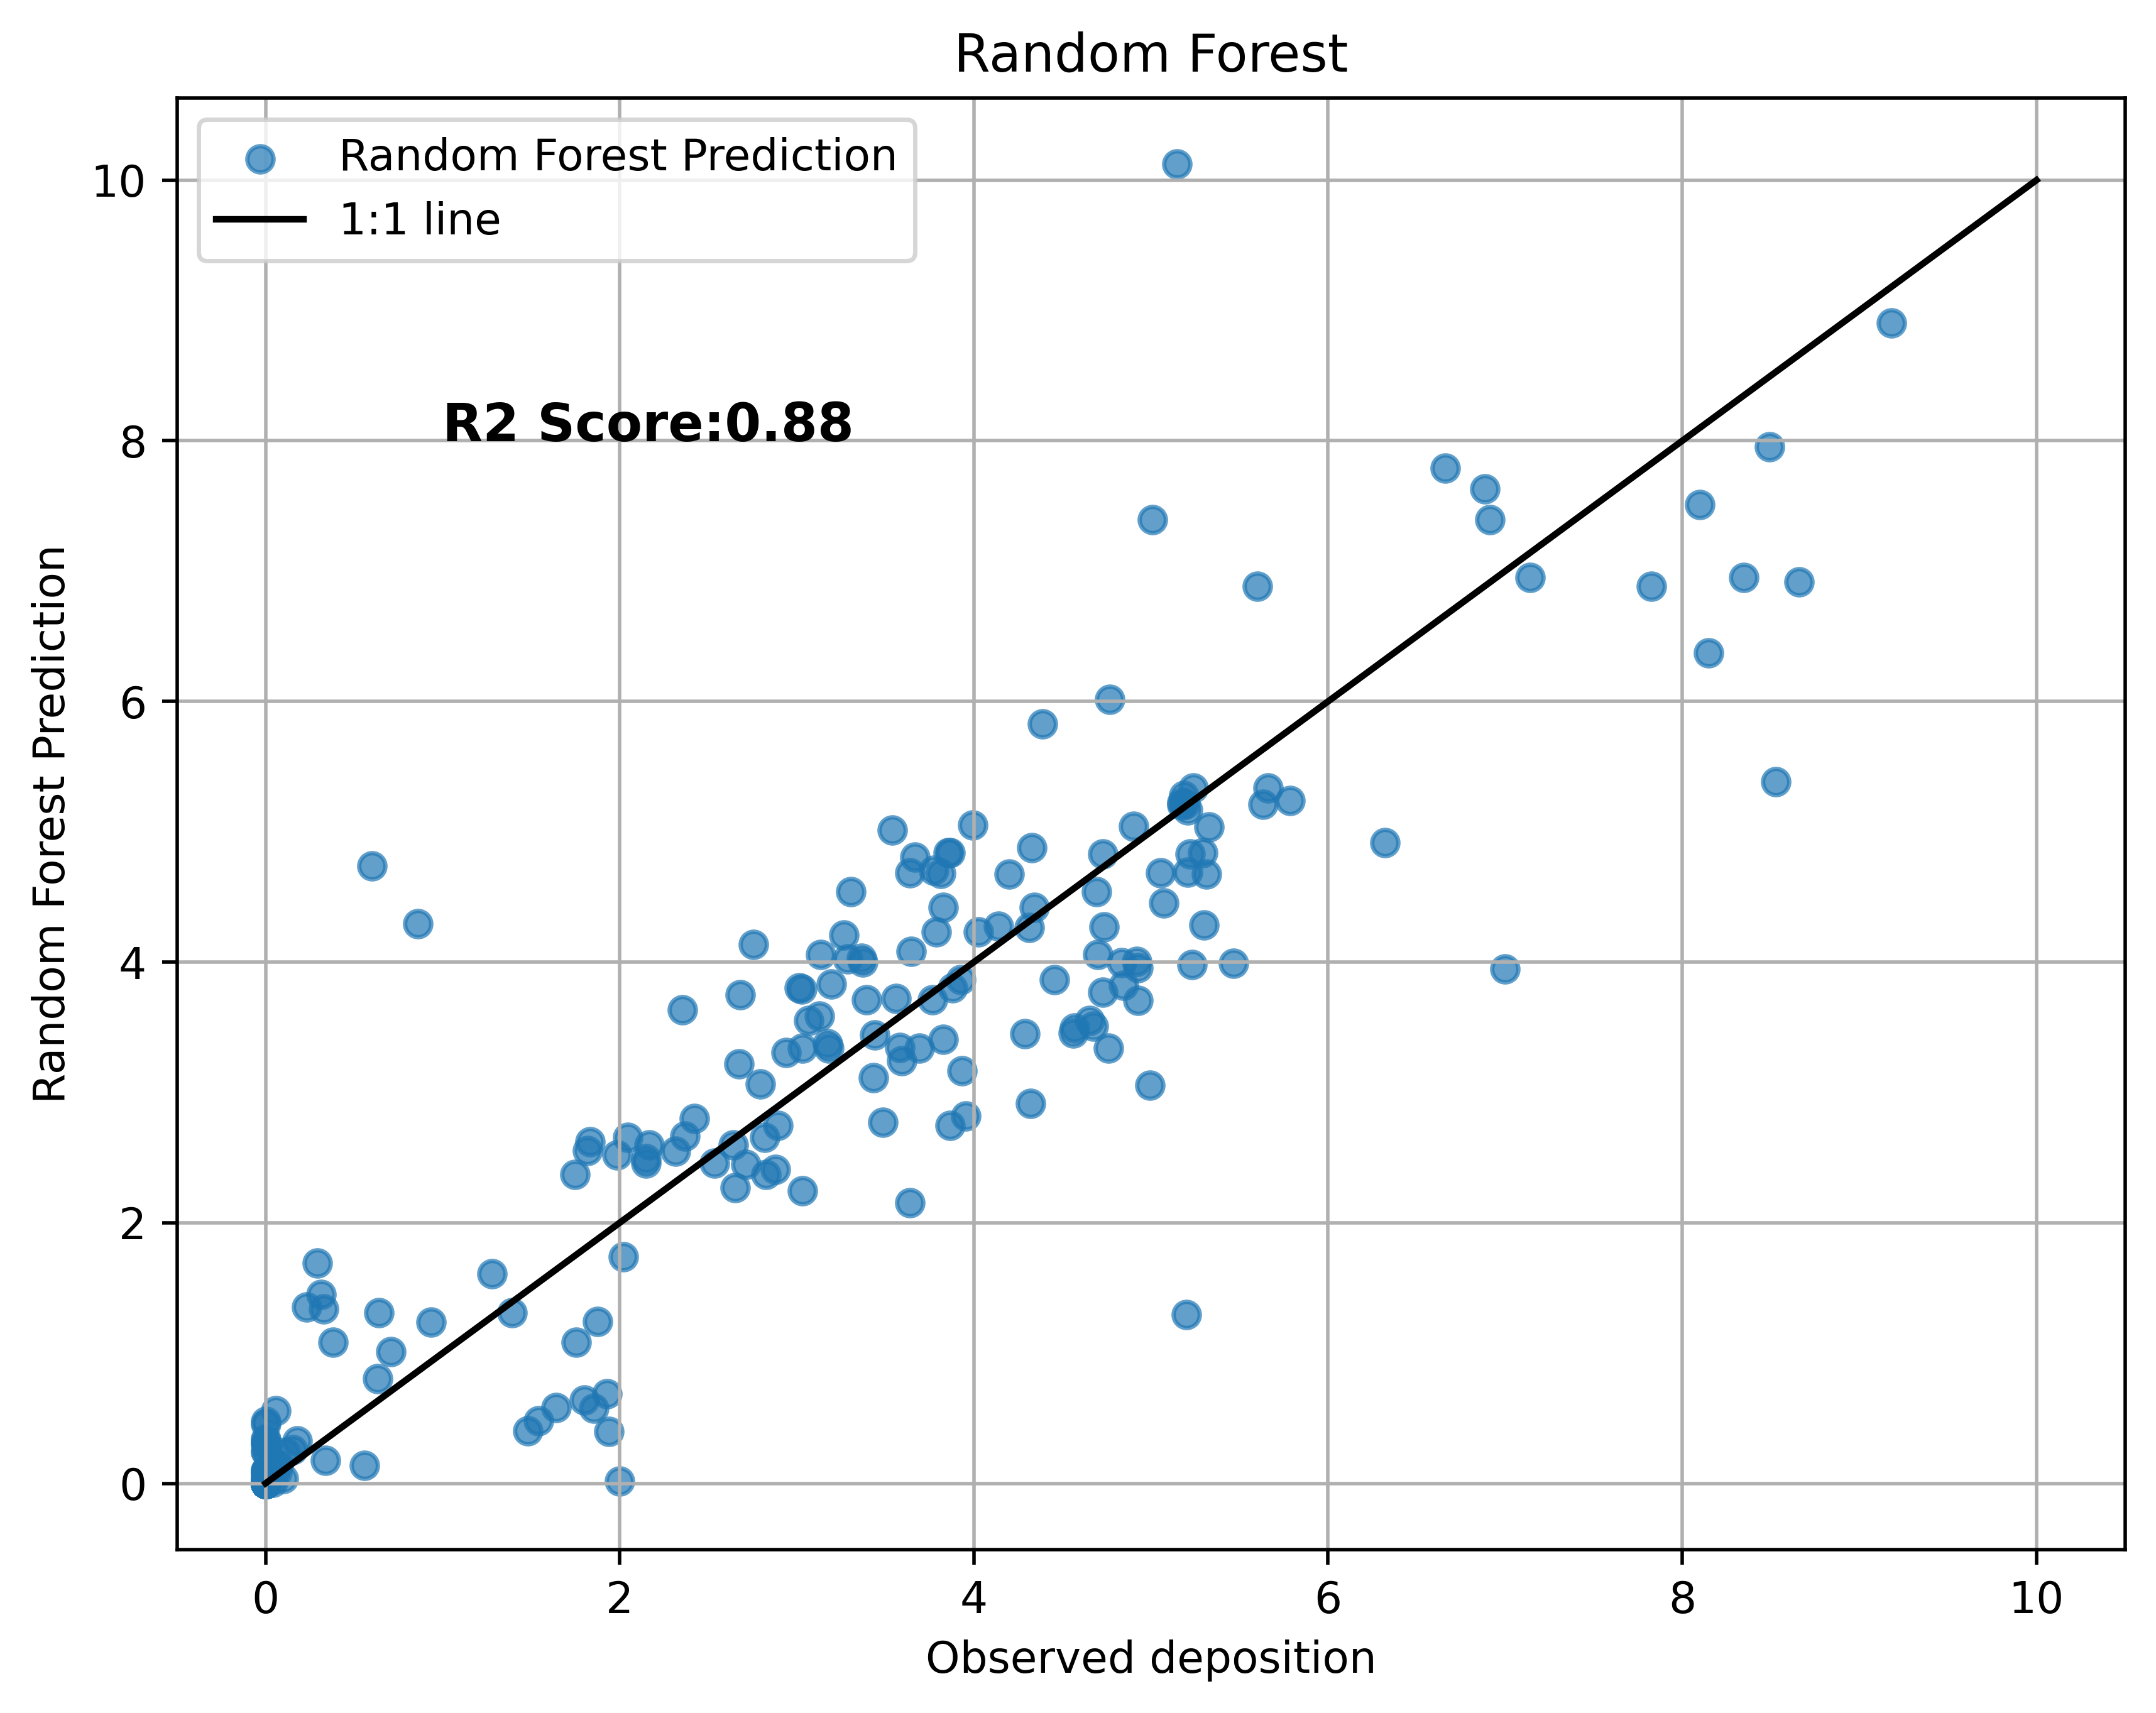

In [38]:
df_37Y_melt = df_37Y_melt.rename(columns={"variable":"diameter"})
df_37Y_melt = df_37Y_melt.rename(columns={"name":"region in nose"})

df_37Y_melt['region in nose']=df_37Y_melt['region in nose'].astype('float64')
df_37Y_melt['diameter']=df_37Y_melt['diameter'].astype('float64')


X=df_37Y_melt.loc[:,['Flow Rate[L/min]', 'region in nose', 'diameter','Velocity','Half Cone angle']]
Y =df_37Y_melt.loc[:,'Dose']

from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.model_selection import cross_validate,cross_val_score, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression,Lasso,Lars,LassoLars,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import numpy as np
import matplotlib.pyplot as plt

xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.25,random_state=120)

algorithms = {
     #'Linear Regression': LinearRegression(),
     #'Lasso Regression': Lasso(),
     #'Lars Regression': Lars(),
     #'Lasso Lars Regression': LassoLars(),
     #'ElasticNet Regression': ElasticNet(),
     #'KNN-U Regression': KNeighborsRegressor(n_neighbors=5, weights='uniform'),
     #'KNN_D  Regression': KNeighborsRegressor(n_neighbors=5, weights='distance'),
     #'SVR Regression': SVR(kernel='rbf'),
     'Gradient Boosting': GradientBoostingRegressor(random_state=120),
     'HistGradientBoosting_Regression': HistGradientBoostingRegressor(),
     'Random Forest': RandomForestRegressor(random_state=120),
     #'MLP Regression': MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20)),
}

for alg in algorithms:

    print(alg,':')
    
    algorithms[alg].fit(xtrain,ytrain)
    ypred=algorithms[alg].predict(xtest)

    scores = cross_validate(algorithms[alg], xtrain,ytrain, cv=KFold(n_splits=5, shuffle=True),
                            scoring=('r2', 'neg_mean_squared_error','neg_mean_absolute_error'),return_train_score=True)

    print('MSE:',round(mean_squared_error(ytest,ypred),4))
    print('MAE:',round(mean_absolute_error(ytest,ypred),4))
    print('Score:',round(r2_score(ytest,ypred),4))
    
    plt.figure(figsize=(8, 6), dpi = 500)
    plt.scatter(ytest, ypred, alpha=0.7, label=f'{alg} Prediction')
    x_coordinates = [0, 10]
    y_coordinates = [0, 10]
    plt.plot(x_coordinates, y_coordinates, c='black', label='1:1 line')
    plt.text(1,8, f'R2 Score:{round(r2_score(ytest,ypred),2)}', fontsize=12, fontweight='bold')
    plt.xlabel('Observed deposition')
    plt.ylabel(f'{alg} Prediction')
    plt.title(f'{alg}')
    plt.legend()
    plt.grid(True)
    plt.show()


Gradient Boosting with Hyperparameter Tuning:
Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
MSE: 0.6107
MAE: 0.4285
R2 Score: 0.8866


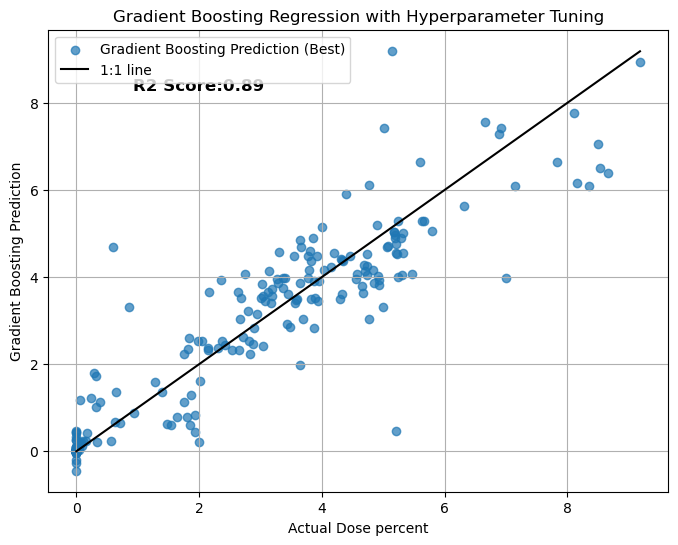

In [39]:
gb_regressor = GradientBoostingRegressor(random_state=120)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(gb_regressor, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(xtrain, ytrain)

best_gb_regressor = grid_search.best_estimator_

ypred_best = best_gb_regressor.predict(xtest)

mse_best = mean_squared_error(ytest, ypred_best)
mae_best = mean_absolute_error(ytest, ypred_best)
r2_best = r2_score(ytest, ypred_best)

print('Gradient Boosting with Hyperparameter Tuning:')
print('Best Parameters:', grid_search.best_params_)
print('MSE:', round(mse_best, 4))
print('MAE:', round(mae_best, 4))
print('R2 Score:', round(r2_best, 4))

plt.figure(figsize=(8, 6))
plt.scatter(ytest, ypred_best, alpha=0.7, label='Gradient Boosting Prediction (Best)')
plt.plot([0, np.max(ytest)], [0, np.max(ytest)], c='black', label='1:1 line')
plt.text(np.max(ytest) * 0.1, np.max(ypred_best) * 0.9, f'R2 Score:{round(r2_best, 2)}', fontsize=12, fontweight='bold')
plt.xlabel('Actual Dose percent')
plt.ylabel('Gradient Boosting Prediction')
plt.title('Gradient Boosting Regression with Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestR

RandomForestRegressor with Hyperparameter Tuning:
Best Parameters: {'max_depth': 10, 'max_features': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
MSE: 0.542
MAE: 0.4019
R2 Score: 0.8993


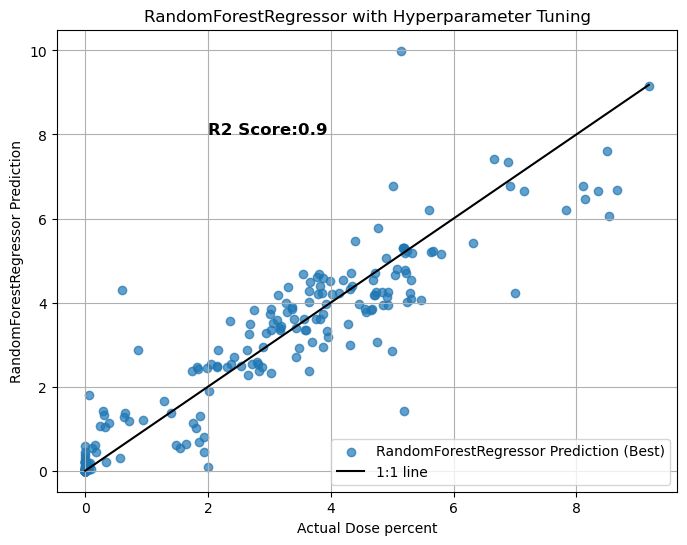

In [40]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf_regressor = RandomForestRegressor(random_state=120)

grid_search = GridSearchCV(rf_regressor, param_grid, cv=5, scoring='r2')
grid_search.fit(xtrain, ytrain)

best_rf_regressor = grid_search.best_estimator_

ypred_best = best_rf_regressor.predict(xtest)

mse_best = mean_squared_error(ytest, ypred_best)
mae_best = mean_absolute_error(ytest, ypred_best)
r2_best = r2_score(ytest, ypred_best)

print('RandomForestRegressor with Hyperparameter Tuning:')
print('Best Parameters:', grid_search.best_params_)
print('MSE:', round(mse_best, 4))
print('MAE:', round(mae_best, 4))
print('R2 Score:', round(r2_best, 4))

plt.figure(figsize=(8, 6))
plt.scatter(ytest, ypred_best, alpha=0.7, label='RandomForestRegressor Prediction (Best)')
plt.plot([0, np.max(ytest)], [0, np.max(ytest)], c='black', label='1:1 line')
plt.text(2, 8, f'R2 Score:{round(r2_best, 2)}', fontsize=12, fontweight='bold')
plt.xlabel('Actual Dose percent')
plt.ylabel('RandomForestRegressor Prediction')
plt.title('RandomForestRegressor with Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()
